In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime

In [2]:
import os

os.listdir()

['.config', '.ipynb_checkpoints', 'data', 'sample_data']

In [3]:
gps = pd.read_csv(
    "data/gps_data.txt",
    sep="\t"
)

gps.head()

,Date (UTC),Time (UTC),Latitude,Longitude,Unnamed: 4,Unnamed: 5
0,17-Jan-2009,20:27:37,47.667483,-122.107083,NaN,NaN
1,17-Jan-2009,20:27:38,47.667500,-122.107067,NaN,NaN
2,17-Jan-2009,20:27:39,47.667500,-122.107067,NaN,NaN
3,17-Jan-2009,20:27:40,47.667517,-122.107033,NaN,NaN
4,17-Jan-2009,20:27:41,47.667533,-122.106983,NaN,NaN


In [4]:
print(gps.shape)
print(gps.columns.tolist())

(7531, 6)
['Date (UTC)', 'Time (UTC)', 'Latitude', 'Longitude', 'Unnamed: 4', 'Unnamed: 5']


In [5]:
gps = gps[
    ["Date (UTC)", "Time (UTC)", "Latitude", "Longitude"]
].copy()

gps.head()

,Date (UTC),Time (UTC),Latitude,Longitude
0,17-Jan-2009,20:27:37,47.667483,-122.107083
1,17-Jan-2009,20:27:38,47.667500,-122.107067
2,17-Jan-2009,20:27:39,47.667500,-122.107067
3,17-Jan-2009,20:27:40,47.667517,-122.107033
4,17-Jan-2009,20:27:41,47.667533,-122.106983


In [6]:
gps["timestamp"] = pd.to_datetime(
    gps["Date (UTC)"] + " " + gps["Time (UTC)"],
    format="%d-%b-%Y %H:%M:%S"
)

gps.head()

,Date (UTC),Time (UTC),Latitude,Longitude,timestamp
0,17-Jan-2009,20:27:37,47.667483,-122.107083,2009-01-17 20:27:37
1,17-Jan-2009,20:27:38,47.667500,-122.107067,2009-01-17 20:27:38
2,17-Jan-2009,20:27:39,47.667500,-122.107067,2009-01-17 20:27:39
3,17-Jan-2009,20:27:40,47.667517,-122.107033,2009-01-17 20:27:40
4,17-Jan-2009,20:27:41,47.667533,-122.106983,2009-01-17 20:27:41


In [7]:
print("Number of GPS observations:", len(gps))

print("\nMissing values:")
print(gps.isnull().sum())

print("\nStart:", gps["timestamp"].min())
print("End:", gps["timestamp"].max())

Number of GPS observations: 7531

Missing values:
Date (UTC)    0
Time (UTC)    0
Latitude      0
Longitude     0
timestamp     0
dtype: int64

Start: 2009-01-17 20:27:37
End: 2009-01-17 22:34:28


In [8]:
gps["time_diff"] = gps["timestamp"].diff().dt.total_seconds()

print(gps["time_diff"].value_counts().sort_index().head(20))

time_diff
1.0     7526
6.0        1
13.0       1
31.0       1
35.0       1
Name: count, dtype: int64


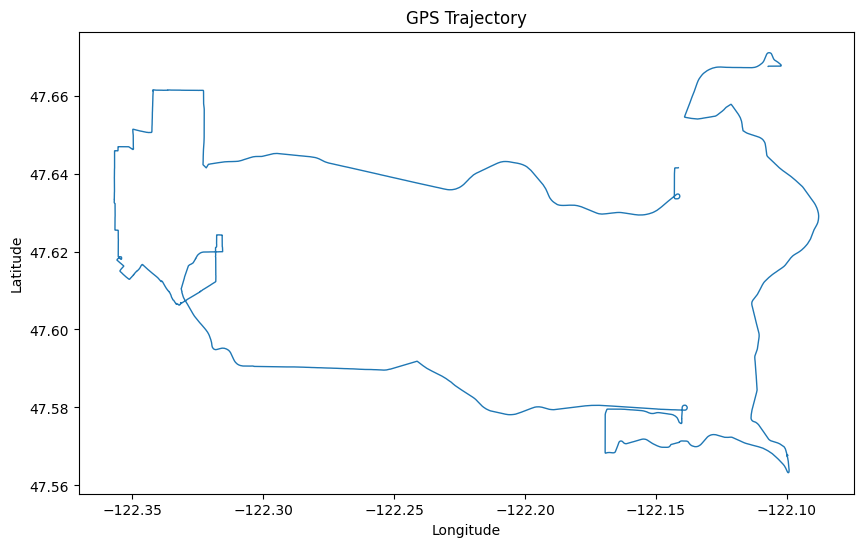

In [9]:
plt.figure(figsize=(10, 6))

plt.plot(
    gps["Longitude"],
    gps["Latitude"],
    linewidth=1
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("GPS Trajectory")

plt.show()

In [10]:
road = pd.read_csv(
    "data/road_network.txt",
    sep="\t"
)

print("Shape:", road.shape)
print("\nColumns:")
print(road.columns.tolist())

road.head()

Shape: (158167, 7)

Columns:
['Edge ID', 'From Node ID', 'To Node ID', 'Two Way', ' Speed (m/s)', 'Vertex Count', 'LINESTRING()']


,Edge ID,From Node ID,To Node ID,Two Way,Speed (m/s),Vertex Count,LINESTRING()
0,883991900000,883991900000,883991900001,1,22.222222,10,"LINESTRING(-122.732318937778 47.8899192810059,..."
1,883991900001,883991900002,883991900003,1,11.111111,4,"LINESTRING(-122.71107852459 47.8776508569717, ..."
2,883991900002,883991900004,883991900005,1,11.111111,29,"LINESTRING(-122.707419991493 47.8761515021324,..."
3,883991900003,883991900004,883991900002,1,11.111111,4,"LINESTRING(-122.707419991493 47.8761515021324,..."
4,883991900004,883991900003,883991900006,1,11.111111,23,"LINESTRING(-122.715329825878 47.8818699717522,..."


In [11]:
print("Number of road edges:", len(road))

print("\nMissing values:")
print(road.isnull().sum())

print("\nTwo-way distribution:")
print(road["Two Way"].value_counts())

print("\nSpeed statistics:")
print(road[" Speed (m/s)"].describe())

Number of road edges: 158167

Missing values:
Edge ID         0
From Node ID    0
To Node ID      0
Two Way         0
 Speed (m/s)    0
Vertex Count    0
LINESTRING()    0
dtype: int64

Two-way distribution:
Two Way
1    148015
0     10152
Name: count, dtype: int64

Speed statistics:
count    158167.000000
mean         11.442933
std           3.468958
min           2.777778
25%          11.111111
50%          11.111111
75%          11.111111
max          31.944444
Name:  Speed (m/s), dtype: float64


In [12]:
ground_truth = pd.read_csv(
    "data/ground_truth_route.txt",
    sep="\t"
)

print("Shape:", ground_truth.shape)

print("\nColumns:")
print(ground_truth.columns.tolist())

ground_truth.head(20)

Shape: (576, 2)

Columns:
['Edge ID', 'Traversed From to To']


,Edge ID,Traversed From to To
0,884147800801,1
1,884147800802,1
2,884147800421,1
3,884147800422,1
4,884147800423,1
5,884147800805,1
6,884147800804,1
7,884147800806,1
8,884147800764,1
9,884147800776,1


In [13]:
print(ground_truth["Edge ID"].nunique())
print(ground_truth["Traversed From to To"].value_counts())

575
Traversed From to To
1    401
0    175
Name: count, dtype: int64


In [14]:
print(ground_truth.columns.tolist())

['Edge ID', 'Traversed From to To']


In [15]:
!pip -q install geopandas shapely pyproj

In [16]:
import geopandas as gpd
from shapely import wkt
from shapely.geometry import Point

In [17]:
road.columns = road.columns.str.strip()

print(road.columns.tolist())

['Edge ID', 'From Node ID', 'To Node ID', 'Two Way', 'Speed (m/s)', 'Vertex Count', 'LINESTRING()']


In [18]:
print(road.shape)
bad = road[~road["LINESTRING()"].astype(str).str.startswith("LINESTRING")]
print("bad rows:", len(bad))
print(bad.head())

(158167, 7)
bad rows: 0
Empty DataFrame
Columns: [Edge ID, From Node ID, To Node ID, Two Way, Speed (m/s), Vertex Count, LINESTRING()]
Index: []


In [19]:
!ls -lh data/

total 32M
-rw-r--r-- 1 root root 346K Oct  4 05:24 gps_data.txt
-rw-r--r-- 1 root root 9.1K Oct  4 05:24 ground_truth_route.txt
-rw-r--r-- 1 root root  31M Oct  4 05:46 road_network.txt


In [20]:
road["geometry"] = road["LINESTRING()"].apply(wkt.loads)

In [21]:
print(road["geometry"].iloc[0])

LINESTRING (-122.732318937778 47.8899192810059, -122.732139229774 47.8903403878212, -122.731820046902 47.8910404443741, -122.731310427189 47.8921294212341, -122.730749845505 47.8933900594711, -122.730208039284 47.894441485405, -122.729588449001 47.8957316279411, -122.729159295559 47.8968098759651, -122.727560698986 47.9000902175903, -122.72741317749 47.900390625)


In [22]:
road_gdf = gpd.GeoDataFrame(
    road,
    geometry="geometry",
    crs="EPSG:4326"
)

print(road_gdf.crs)

EPSG:4326


In [23]:
gps_gdf = gpd.GeoDataFrame(
    gps,
    geometry=gpd.points_from_xy(
        gps["Longitude"],
        gps["Latitude"]
    ),
    crs="EPSG:4326"
)

print(gps_gdf.head())

    Date (UTC) Time (UTC)   Latitude   Longitude           timestamp  \
0  17-Jan-2009   20:27:37  47.667483 -122.107083 2009-01-17 20:27:37   
1  17-Jan-2009   20:27:38  47.667500 -122.107067 2009-01-17 20:27:38   
2  17-Jan-2009   20:27:39  47.667500 -122.107067 2009-01-17 20:27:39   
3  17-Jan-2009   20:27:40  47.667517 -122.107033 2009-01-17 20:27:40   
4  17-Jan-2009   20:27:41  47.667533 -122.106983 2009-01-17 20:27:41   

   time_diff                     geometry  
0        NaN  POINT (-122.10708 47.66748)  
1        1.0   POINT (-122.10707 47.6675)  
2        1.0   POINT (-122.10707 47.6675)  
3        1.0  POINT (-122.10703 47.66752)  
4        1.0  POINT (-122.10698 47.66753)  


In [24]:
import geopandas as gpd

# Create GPS GeoDataFrame
gps_gdf = gpd.GeoDataFrame(
    gps,
    geometry=gpd.points_from_xy(
        gps["Longitude"],
        gps["Latitude"]
    ),
    crs="EPSG:4326"
)

# Convert latitude/longitude to meters
gps_projected = gps_gdf.to_crs("EPSG:32610")

print("GPS projected successfully!")
print(gps_projected.head())

GPS projected successfully!
    Date (UTC) Time (UTC)   Latitude   Longitude           timestamp  \
0  17-Jan-2009   20:27:37  47.667483 -122.107083 2009-01-17 20:27:37   
1  17-Jan-2009   20:27:38  47.667500 -122.107067 2009-01-17 20:27:38   
2  17-Jan-2009   20:27:39  47.667500 -122.107067 2009-01-17 20:27:39   
3  17-Jan-2009   20:27:40  47.667517 -122.107033 2009-01-17 20:27:40   
4  17-Jan-2009   20:27:41  47.667533 -122.106983 2009-01-17 20:27:41   

   time_diff                        geometry  
0        NaN  POINT (567034.213 5279729.609)  
1        1.0  POINT (567035.438 5279731.476)  
2        1.0  POINT (567035.438 5279731.476)  
3        1.0  POINT (567037.924 5279733.357)  
4        1.0  POINT (567041.657 5279735.252)  


In [25]:
# Convert road network WKT strings into Shapely geometries
from shapely import wkt
import geopandas as gpd

road["geometry"] = road["LINESTRING()"].apply(wkt.loads)

# Create GeoDataFrame
road_gdf = gpd.GeoDataFrame(
    road,
    geometry="geometry",
    crs="EPSG:4326"
)

# Project road network to meters
road_projected = road_gdf.to_crs("EPSG:32610")

print("Road network projected successfully!")
print(road_projected.head())

Road network projected successfully!
        Edge ID  From Node ID    To Node ID  Two Way  Speed (m/s)  \
0  883991900000  883991900000  883991900001        1    22.222222   
1  883991900001  883991900002  883991900003        1    11.111111   
2  883991900002  883991900004  883991900005        1    11.111111   
3  883991900003  883991900004  883991900002        1    11.111111   
4  883991900004  883991900003  883991900006        1    11.111111   

   Vertex Count                                       LINESTRING()  \
0            10  LINESTRING(-122.732318937778 47.8899192810059,...   
1             4  LINESTRING(-122.71107852459 47.8776508569717, ...   
2            29  LINESTRING(-122.707419991493 47.8761515021324,...   
3             4  LINESTRING(-122.707419991493 47.8761515021324,...   
4            23  LINESTRING(-122.715329825878 47.8818699717522,...   

                                            geometry  
0  LINESTRING (520010.238 5304100.004, 520023.51 ...  
1  LINESTRING (52

In [26]:
# Take the first GPS observation
test_point = gps_projected.geometry.iloc[0]

# Temporary radius for testing
search_radius = 50  # meters

# Find roads within 50 meters
nearby = road_projected[
    road_projected.geometry.distance(test_point) <= search_radius
].copy()

print("Number of candidate roads:", len(nearby))

print(nearby[[
    "Edge ID",
    "Speed (m/s)"
]].head())

Number of candidate roads: 1
            Edge ID  Speed (m/s)
88269  884147800801    11.111111


In [27]:
# Build spatial index for the road network
road_index = road_projected.sindex

print("Spatial index created successfully!")

Spatial index created successfully!


In [28]:
# First GPS point
test_point = gps_projected.geometry.iloc[0]

# Temporary candidate radius
search_radius = 50  # meters

# Use spatial index to find nearby road bounding boxes
possible_idx = road_index.query(
    test_point.buffer(search_radius),
    predicate="intersects"
)

# Get those road segments
nearby = road_projected.iloc[possible_idx].copy()

# Calculate exact distance
nearby["distance_m"] = nearby.geometry.distance(test_point)

# Keep only roads actually within 50 m
nearby = nearby[
    nearby["distance_m"] <= search_radius
].copy()

# Sort by distance
nearby = nearby.sort_values("distance_m")

print("Number of candidate roads:", len(nearby))

print(
    nearby[
        ["Edge ID", "Speed (m/s)", "distance_m"]
    ].head(10)
)

Number of candidate roads: 1
            Edge ID  Speed (m/s)  distance_m
88269  884147800801    11.111111    5.112974


In [29]:
candidate_radius = 50  # meters

all_candidates = []

for i, point in enumerate(gps_projected.geometry):

    # Find possible nearby roads using spatial index
    possible_idx = road_index.query(
        point.buffer(candidate_radius),
        predicate="intersects"
    )

    # Get candidate roads
    candidates = road_projected.iloc[possible_idx].copy()

    # Exact distance
    candidates["distance_m"] = candidates.geometry.distance(point)

    # Keep only roads within radius
    candidates = candidates[
        candidates["distance_m"] <= candidate_radius
    ].copy()

    # Store GPS observation index
    candidates["gps_index"] = i

    all_candidates.append(
        candidates[
            [
                "gps_index",
                "Edge ID",
                "From Node ID",
                "To Node ID",
                "Two Way",
                "Speed (m/s)",
                "distance_m"
            ]
        ]
    )

    if i % 1000 == 0:
        print(f"Processed {i}/{len(gps_projected)} GPS points")

# Combine everything
candidate_df = pd.concat(
    all_candidates,
    ignore_index=True
)

print("\nCandidate generation complete!")
print("Total candidate records:", len(candidate_df))
print("GPS observations:", len(gps_projected))

Processed 0/7531 GPS points
Processed 1000/7531 GPS points
Processed 2000/7531 GPS points
Processed 3000/7531 GPS points
Processed 4000/7531 GPS points
Processed 5000/7531 GPS points
Processed 6000/7531 GPS points
Processed 7000/7531 GPS points

Candidate generation complete!
Total candidate records: 33566
GPS observations: 7531


In [30]:
candidate_counts = (
    candidate_df
    .groupby("gps_index")
    .size()
)

print(candidate_counts.describe())

count    7531.000000
mean        4.457044
std         2.303553
min         1.000000
25%         3.000000
50%         4.000000
75%         6.000000
max        21.000000
dtype: float64


In [31]:
zero_candidates = (
    len(gps_projected)
    - candidate_counts.index.nunique()
)

print("GPS points with zero candidates:", zero_candidates)

GPS points with zero candidates: 0


In [32]:
candidate_df["distance_m"].describe()

,distance_m
count,33566.000000
mean,20.463046
std,15.326415
min,0.000011
25%,6.100236
50%,17.907456
75%,34.192648
max,49.975982


In [33]:
candidate_df[[
    "gps_index",
    "Edge ID",
    "distance_m"
]].head(10)

,gps_index,Edge ID,distance_m
0,0,884147800801,5.112974
1,1,884147800801,3.254902
2,2,884147800801,3.254902
3,3,884147800801,1.402133
4,4,884147800801,0.449515
5,5,884147800801,0.449469
6,6,884147800801,1.402267
7,7,884147800801,1.402320
8,8,884147800801,1.402375
9,9,884147800801,1.402413


In [34]:
# Estimate sigma from candidate GPS-to-road distances
sigma = candidate_df["distance_m"].std()

print("Estimated sigma:", sigma)

Estimated sigma: 15.326414889692936


In [35]:
import numpy as np

candidate_df["location_emission"] = np.exp(
    -(candidate_df["distance_m"] ** 2) /
    (2 * sigma ** 2)
)

print(candidate_df[[
    "gps_index",
    "Edge ID",
    "distance_m",
    "location_emission"
]].head(10))

   gps_index       Edge ID  distance_m  location_emission
0          0  884147800801    5.112974           0.945874
1          1  884147800801    3.254902           0.977701
2          2  884147800801    3.254902           0.977701
3          3  884147800801    1.402133           0.995824
4          4  884147800801    0.449515           0.999570
5          5  884147800801    0.449469           0.999570
6          6  884147800801    1.402267           0.995823
7          7  884147800801    1.402320           0.995823
8          8  884147800801    1.402375           0.995823
9          9  884147800801    1.402413           0.995822


In [36]:
# Calculate movement between consecutive GPS observations

gps_projected["dx"] = gps_projected.geometry.x.diff()
gps_projected["dy"] = gps_projected.geometry.y.diff()

# Movement distance
gps_projected["movement_distance"] = np.sqrt(
    gps_projected["dx"]**2 +
    gps_projected["dy"]**2
)

# Unit movement vector
gps_projected["velocity_x"] = (
    gps_projected["dx"] /
    gps_projected["movement_distance"]
)

gps_projected["velocity_y"] = (
    gps_projected["dy"] /
    gps_projected["movement_distance"]
)

print(
    gps_projected[
        ["dx", "dy", "velocity_x", "velocity_y"]
    ].head()
)

         dx        dy  velocity_x  velocity_y
0       NaN       NaN         NaN         NaN
1  1.224861  1.867031    0.548538    0.836126
2  0.000000  0.000000         NaN         NaN
3  2.486082  1.881564    0.797375    0.603484
4  3.732300  1.894813    0.891671    0.452683


In [37]:
# Get start and end coordinates of each road segment

road_projected["start_x"] = road_projected.geometry.apply(
    lambda geom: geom.coords[0][0]
)

road_projected["start_y"] = road_projected.geometry.apply(
    lambda geom: geom.coords[0][1]
)

road_projected["end_x"] = road_projected.geometry.apply(
    lambda geom: geom.coords[-1][0]
)

road_projected["end_y"] = road_projected.geometry.apply(
    lambda geom: geom.coords[-1][1]
)

# Road direction vector
road_projected["road_dx"] = (
    road_projected["end_x"] -
    road_projected["start_x"]
)

road_projected["road_dy"] = (
    road_projected["end_y"] -
    road_projected["start_y"]
)

# Road length
road_length = np.sqrt(
    road_projected["road_dx"]**2 +
    road_projected["road_dy"]**2
)

# Unit road direction
road_projected["road_unit_x"] = (
    road_projected["road_dx"] / road_length
)

road_projected["road_unit_y"] = (
    road_projected["road_dy"] / road_length
)

print(
    road_projected[
        ["Edge ID", "road_unit_x", "road_unit_y"]
    ].head()
)

        Edge ID  road_unit_x  road_unit_y
0  883991900000     0.297171     0.954824
1  883991900001    -0.564164     0.825663
2  883991900002     0.398747     0.917061
3  883991900003    -0.855971     0.517024
4  883991900004    -0.300444     0.953800


In [38]:
# Keep only the road direction information we need
road_direction = road_projected[
    ["Edge ID", "road_unit_x", "road_unit_y"]
].copy()

# Add road direction to every candidate
candidate_df = candidate_df.merge(
    road_direction,
    on="Edge ID",
    how="left"
)

print(candidate_df[
    [
        "gps_index",
        "Edge ID",
        "distance_m",
        "road_unit_x",
        "road_unit_y"
    ]
].head(10))

   gps_index       Edge ID  distance_m  road_unit_x  road_unit_y
0          0  884147800801    5.112974     0.996047     0.088822
1          1  884147800801    3.254902     0.996047     0.088822
2          2  884147800801    3.254902     0.996047     0.088822
3          3  884147800801    1.402133     0.996047     0.088822
4          4  884147800801    0.449515     0.996047     0.088822
5          5  884147800801    0.449469     0.996047     0.088822
6          6  884147800801    1.402267     0.996047     0.088822
7          7  884147800801    1.402320     0.996047     0.088822
8          8  884147800801    1.402375     0.996047     0.088822
9          9  884147800801    1.402413     0.996047     0.088822


In [39]:
gps_direction = gps_projected[
    ["velocity_x", "velocity_y"]
].copy()

gps_direction["gps_index"] = gps_direction.index

candidate_df = candidate_df.merge(
    gps_direction,
    on="gps_index",
    how="left"
)

print(candidate_df[
    [
        "gps_index",
        "Edge ID",
        "velocity_x",
        "velocity_y",
        "road_unit_x",
        "road_unit_y"
    ]
].head(10))

   gps_index       Edge ID  velocity_x  velocity_y  road_unit_x  road_unit_y
0          0  884147800801         NaN         NaN     0.996047     0.088822
1          1  884147800801    0.548538    0.836126     0.996047     0.088822
2          2  884147800801         NaN         NaN     0.996047     0.088822
3          3  884147800801    0.797375    0.603484     0.996047     0.088822
4          4  884147800801    0.891671    0.452683     0.996047     0.088822
5          5  884147800801    0.999934    0.011523     0.996047     0.088822
6          6  884147800801    0.962151   -0.272517     0.996047     0.088822
7          7  884147800801    0.999934    0.011525     0.996047     0.088822
8          8  884147800801    0.999934    0.011526     0.996047     0.088822
9          9  884147800801    0.999934    0.011528     0.996047     0.088822


In [40]:
candidate_df["orientation"] = (
    candidate_df["velocity_x"] * candidate_df["road_unit_x"]
    +
    candidate_df["velocity_y"] * candidate_df["road_unit_y"]
)

In [41]:
candidate_df["orientation"] = (
    candidate_df["orientation"]
    .fillna(0)
    .clip(-1, 1)
)

In [42]:
print(
    candidate_df[
        [
            "gps_index",
            "Edge ID",
            "orientation"
        ]
    ].head(20)
)

    gps_index       Edge ID  orientation
0           0  884147800801     0.000000
1           1  884147800801     0.620637
2           2  884147800801     0.000000
3           3  884147800801     0.847826
4           4  884147800801     0.928355
5           5  884147800801     0.997005
6           6  884147800801     0.934143
7           7  884147800801     0.997005
8           8  884147800801     0.997005
9           9  884147800801     0.997005
10         10  884147800801     0.997005
11         11  884147800801     0.997006
12         12  884147802854     0.041537
13         12  884147800801     0.997006
14         13  884147802854     0.041539
15         13  884147800801     0.997006
16         13  884147800802     0.998316
17         14  884147802854     0.041540
18         14  884147800801     0.997006
19         14  884147800802     0.998316


In [43]:
# Add road direction information to candidate dataframe
road_info = road_projected[
    [
        "Edge ID",
        "Two Way",
        "road_unit_x",
        "road_unit_y"
    ]
].copy()

candidate_df = candidate_df.drop(
    columns=["Two Way", "road_unit_x", "road_unit_y"],
    errors="ignore"
)

candidate_df = candidate_df.merge(
    road_info,
    on="Edge ID",
    how="left"
)

print(candidate_df[
    ["gps_index", "Edge ID", "Two Way",
     "road_unit_x", "road_unit_y"]
].head())

   gps_index       Edge ID  Two Way  road_unit_x  road_unit_y
0          0  884147800801        1     0.996047     0.088822
1          1  884147800801        1     0.996047     0.088822
2          2  884147800801        1     0.996047     0.088822
3          3  884147800801        1     0.996047     0.088822
4          4  884147800801        1     0.996047     0.088822


In [44]:
# Forward direction
candidate_df["direction"] = 1

candidate_df["state_road_x"] = candidate_df["road_unit_x"]
candidate_df["state_road_y"] = candidate_df["road_unit_y"]

In [45]:
# Create reverse-direction states for two-way roads
reverse_candidates = candidate_df[
    candidate_df["Two Way"] == 1
].copy()

reverse_candidates["direction"] = -1

reverse_candidates["state_road_x"] = -reverse_candidates["road_unit_x"]
reverse_candidates["state_road_y"] = -reverse_candidates["road_unit_y"]

# Combine forward + reverse states
candidate_df = pd.concat(
    [candidate_df, reverse_candidates],
    ignore_index=True
)

print("Total directed candidate states:", len(candidate_df))

print(
    candidate_df[
        [
            "gps_index",
            "Edge ID",
            "direction",
            "state_road_x",
            "state_road_y"
        ]
    ].head(10)
)

Total directed candidate states: 55484
   gps_index       Edge ID  direction  state_road_x  state_road_y
0          0  884147800801          1      0.996047      0.088822
1          1  884147800801          1      0.996047      0.088822
2          2  884147800801          1      0.996047      0.088822
3          3  884147800801          1      0.996047      0.088822
4          4  884147800801          1      0.996047      0.088822
5          5  884147800801          1      0.996047      0.088822
6          6  884147800801          1      0.996047      0.088822
7          7  884147800801          1      0.996047      0.088822
8          8  884147800801          1      0.996047      0.088822
9          9  884147800801          1      0.996047      0.088822


In [46]:
candidate_df["orientation"] = (
    candidate_df["velocity_x"] * candidate_df["state_road_x"]
    +
    candidate_df["velocity_y"] * candidate_df["state_road_y"]
)

candidate_df["orientation"] = (
    candidate_df["orientation"]
    .fillna(0)
    .clip(-1, 1)
)

print(
    candidate_df[
        [
            "gps_index",
            "Edge ID",
            "direction",
            "orientation"
        ]
    ].head(20)
)

    gps_index       Edge ID  direction  orientation
0           0  884147800801          1     0.000000
1           1  884147800801          1     0.620637
2           2  884147800801          1     0.000000
3           3  884147800801          1     0.847826
4           4  884147800801          1     0.928355
5           5  884147800801          1     0.997005
6           6  884147800801          1     0.934143
7           7  884147800801          1     0.997005
8           8  884147800801          1     0.997005
9           9  884147800801          1     0.997005
10         10  884147800801          1     0.997005
11         11  884147800801          1     0.997006
12         12  884147802854          1     0.041537
13         12  884147800801          1     0.997006
14         13  884147802854          1     0.041539
15         13  884147800801          1     0.997006
16         13  884147800802          1     0.998316
17         14  884147802854          1     0.041540
18         1

In [47]:
# GPS speed in m/s
gps_projected["gps_speed_mps"] = (
    gps_projected["movement_distance"] /
    gps_projected["time_diff"]
)

# Add GPS speed to candidate states
gps_speed = gps_projected[
    ["gps_speed_mps"]
].copy()

gps_speed["gps_index"] = gps_speed.index

candidate_df = candidate_df.merge(
    gps_speed,
    on="gps_index",
    how="left"
)

print(
    candidate_df[
        ["gps_index", "gps_speed_mps"]
    ].head(10)
)

   gps_index  gps_speed_mps
0          0            NaN
1          1       2.232956
2          2       0.000000
3          3       3.117834
4          4       4.185735
5          5       5.000173
6          6       6.529537
7          7       7.507769
8          8      10.007856
9          9      10.007857


In [48]:
# 40 mph converted to m/s
speed_threshold = 40 * 0.44704

candidate_df["speed_constraint"] = np.where(
    (candidate_df["gps_speed_mps"] > speed_threshold) &
    (
        candidate_df["gps_speed_mps"]
        > 1.20 * candidate_df["Speed (m/s)"]
    ),
    0,
    1
)

print(
    candidate_df[
        [
            "gps_index",
            "Edge ID",
            "gps_speed_mps",
            "Speed (m/s)",
            "speed_constraint"
        ]
    ].head(20)
)

    gps_index       Edge ID  gps_speed_mps  Speed (m/s)  speed_constraint
0           0  884147800801            NaN    11.111111                 1
1           1  884147800801       2.232956    11.111111                 1
2           2  884147800801       0.000000    11.111111                 1
3           3  884147800801       3.117834    11.111111                 1
4           4  884147800801       4.185735    11.111111                 1
5           5  884147800801       5.000173    11.111111                 1
6           6  884147800801       6.529537    11.111111                 1
7           7  884147800801       7.507769    11.111111                 1
8           8  884147800801      10.007856    11.111111                 1
9           9  884147800801      10.007857    11.111111                 1
10         10  884147800801      10.015365    11.111111                 1
11         11  884147800801      10.007857    11.111111                 1
12         12  884147802854      10.00

In [49]:
road_projected["midpoint"] = road_projected.geometry.interpolate(0.5, normalized=True)

road_midpoints = road_projected[
    ["Edge ID", "midpoint"]
].copy()

print(road_midpoints.head())

        Edge ID                        midpoint
0  883991900000  POINT (520191.619 5304682.568)
1  883991900001  POINT (521441.735 5302974.935)
2  883991900002  POINT (522125.466 5303221.991)
3  883991900003  POINT (521732.519 5302644.584)
4  883991900004  POINT (520807.451 5304195.157)


In [50]:
candidate_df = candidate_df.drop(
    columns=["midpoint"],
    errors="ignore"
)

candidate_df = candidate_df.merge(
    road_midpoints,
    on="Edge ID",
    how="left"
)

print(
    candidate_df[
        ["gps_index", "Edge ID", "midpoint"]
    ].head()
)

   gps_index       Edge ID                       midpoint
0          0  884147800801  POINT (566992.787 5279735.48)
1          1  884147800801  POINT (566992.787 5279735.48)
2          2  884147800801  POINT (566992.787 5279735.48)
3          3  884147800801  POINT (566992.787 5279735.48)
4          4  884147800801  POINT (566992.787 5279735.48)


In [51]:
gps_projected["movement_distance"]

,movement_distance
0,NaN
1,2.232956
2,0.000000
3,3.117834
4,4.185735
...,...
7526,12.650528
7527,10.020307
7528,10.182775
7529,10.182775


In [52]:
gps_transition = gps_projected[
    ["movement_distance"]
].copy()

gps_transition["gps_index"] = gps_transition.index

candidate_df = candidate_df.merge(
    gps_transition,
    on="gps_index",
    how="left",
    suffixes=("", "_gps")
)

print(
    candidate_df[
        ["gps_index", "movement_distance"]
    ].head(10)
)

   gps_index  movement_distance
0          0                NaN
1          1           2.232956
2          2           0.000000
3          3           3.117834
4          4           4.185735
5          5           5.000173
6          6           6.529537
7          7           7.507769
8          8          10.007856
9          9          10.007857


In [53]:
state_info = candidate_df[
    [
        "gps_index",
        "Edge ID",
        "direction",
        "state_road_x",
        "state_road_y",
        "midpoint"
    ]
].copy()

print(state_info.head())

   gps_index       Edge ID  direction  state_road_x  state_road_y  \
0          0  884147800801          1      0.996047      0.088822   
1          1  884147800801          1      0.996047      0.088822   
2          2  884147800801          1      0.996047      0.088822   
3          3  884147800801          1      0.996047      0.088822   
4          4  884147800801          1      0.996047      0.088822   

                        midpoint  
0  POINT (566992.787 5279735.48)  
1  POINT (566992.787 5279735.48)  
2  POINT (566992.787 5279735.48)  
3  POINT (566992.787 5279735.48)  
4  POINT (566992.787 5279735.48)  


In [54]:
t = 11

previous_states = state_info[
    state_info["gps_index"] == t - 1
].copy()

current_states = state_info[
    state_info["gps_index"] == t
].copy()

print("Previous states:", len(previous_states))
print("Current states:", len(current_states))

Previous states: 2
Current states: 2


In [55]:
transitions = (
    previous_states.assign(key=1)
    .merge(
        current_states.assign(key=1),
        on="key",
        suffixes=("_prev", "_curr")
    )
    .drop(columns="key")
)

print("Possible transitions:", len(transitions))

Possible transitions: 4


In [56]:
# Calculate distance between the two road midpoints
transitions["road_distance"] = transitions.apply(
    lambda row: row["midpoint_prev"].distance(
        row["midpoint_curr"]
    ),
    axis=1
)

print(
    transitions[
        [
            "Edge ID_prev",
            "Edge ID_curr",
            "road_distance"
        ]
    ].head(10)
)

   Edge ID_prev  Edge ID_curr  road_distance
0  884147800801  884147800801            0.0
1  884147800801  884147800801            0.0
2  884147800801  884147800801            0.0
3  884147800801  884147800801            0.0


In [57]:
gps_distance = gps_projected.loc[
    t,
    "movement_distance"
]

print("GPS movement distance:", gps_distance)

GPS movement distance: 10.007856950353112


In [58]:
transitions["distance_discrepancy"] = 1 / (
    abs(
        gps_distance -
        transitions["road_distance"]
    ) + 1
)

print(
    transitions[
        [
            "Edge ID_prev",
            "Edge ID_curr",
            "road_distance",
            "distance_discrepancy"
        ]
    ].head(10)
)

   Edge ID_prev  Edge ID_curr  road_distance  distance_discrepancy
0  884147800801  884147800801            0.0              0.090844
1  884147800801  884147800801            0.0              0.090844
2  884147800801  884147800801            0.0              0.090844
3  884147800801  884147800801            0.0              0.090844


In [59]:
previous_edge = transitions["Edge ID_prev"]
current_edge = transitions["Edge ID_curr"]

transitions["backtrack_prevention"] = np.where(
    current_edge == previous_edge,
    0,
    1
)

print(
    transitions[
        [
            "Edge ID_prev",
            "Edge ID_curr",
            "backtrack_prevention"
        ]
    ].head(10)
)

   Edge ID_prev  Edge ID_curr  backtrack_prevention
0  884147800801  884147800801                     0
1  884147800801  884147800801                     0
2  884147800801  884147800801                     0
3  884147800801  884147800801                     0


In [60]:
print(
    transitions[
        [
            "Edge ID_prev",
            "Edge ID_curr",
            "distance_discrepancy",
            "backtrack_prevention"
        ]
    ].head(20)
)

   Edge ID_prev  Edge ID_curr  distance_discrepancy  backtrack_prevention
0  884147800801  884147800801              0.090844                     0
1  884147800801  884147800801              0.090844                     0
2  884147800801  884147800801              0.090844                     0
3  884147800801  884147800801              0.090844                     0


In [61]:
def build_transitions_for_time(t):
    previous_states = state_info[
        state_info["gps_index"] == t - 1
    ].copy()

    current_states = state_info[
        state_info["gps_index"] == t
    ].copy()

    if len(previous_states) == 0 or len(current_states) == 0:
        return None

    # Cartesian product: every previous candidate
    # with every current candidate
    transitions = (
        previous_states.assign(key=1)
        .merge(
            current_states.assign(key=1),
            on="key",
            suffixes=("_prev", "_curr")
        )
        .drop(columns="key")
    )

    # GPS movement distance
    gps_distance = gps_projected.loc[
        t,
        "movement_distance"
    ]

    # Distance between candidate road midpoints
    transitions["road_distance"] = transitions.apply(
        lambda row: row["midpoint_prev"].distance(
            row["midpoint_curr"]
        ),
        axis=1
    )

    # Distance discrepancy
    transitions["distance_discrepancy"] = 1 / (
        abs(
            gps_distance -
            transitions["road_distance"]
        ) + 1
    )

    # Local backtrack prevention
    transitions["backtrack_prevention"] = np.where(
        transitions["Edge ID_curr"]
        == transitions["Edge ID_prev"],
        0,
        1
    )

    transitions["gps_index"] = t

    return transitions

In [62]:
test_transitions = build_transitions_for_time(11)

print(
    test_transitions[
        [
            "gps_index",
            "Edge ID_prev",
            "Edge ID_curr",
            "distance_discrepancy",
            "backtrack_prevention"
        ]
    ].head(20)
)

print(
    "Number of transitions:",
    len(test_transitions)
)

   gps_index  Edge ID_prev  Edge ID_curr  distance_discrepancy  \
0         11  884147800801  884147800801              0.090844   
1         11  884147800801  884147800801              0.090844   
2         11  884147800801  884147800801              0.090844   
3         11  884147800801  884147800801              0.090844   

   backtrack_prevention  
0                     0  
1                     0  
2                     0  
3                     0  
Number of transitions: 4


In [63]:
# Check duplicate candidate states
duplicate_check = (
    state_info
    .groupby(["gps_index", "Edge ID", "direction"])
    .size()
    .reset_index(name="count")
)

print(
    duplicate_check[
        duplicate_check["count"] > 1
    ].head(20)
)

Empty DataFrame
Columns: [gps_index, Edge ID, direction, count]
Index: []


In [64]:
print(
    "Total state rows:",
    len(state_info)
)

print(
    "Unique GPS + Edge + Direction states:",
    state_info[
        ["gps_index", "Edge ID", "direction"]
    ].drop_duplicates().shape[0]
)

Total state rows: 55484
Unique GPS + Edge + Direction states: 55484


In [65]:
state_counts = (
    state_info
    .groupby("gps_index")
    .size()
)

estimated_transitions = (
    state_counts.shift(1) * state_counts
).sum()

print("Estimated total transitions:", int(estimated_transitions))
print("Average states per GPS:", state_counts.mean())
print("Maximum states for one GPS:", state_counts.max())

Estimated total transitions: 509662
Average states per GPS: 7.367414685964679
Maximum states for one GPS: 27


In [66]:
all_transitions = []

for t in range(1, len(gps_projected)):

    transitions_t = build_transitions_for_time(t)

    if transitions_t is not None:
        all_transitions.append(transitions_t)

    if t % 1000 == 0:
        print(f"Processed {t}/{len(gps_projected)-1} transitions")

transition_df = pd.concat(
    all_transitions,
    ignore_index=True
)

print("\nComplete transition table created!")
print("Total transitions:", len(transition_df))

Processed 1000/7530 transitions
Processed 2000/7530 transitions
Processed 3000/7530 transitions
Processed 4000/7530 transitions
Processed 5000/7530 transitions
Processed 6000/7530 transitions
Processed 7000/7530 transitions

Complete transition table created!
Total transitions: 509662


In [67]:
print(
    transition_df[
        [
            "gps_index",
            "Edge ID_prev",
            "Edge ID_curr",
            "distance_discrepancy",
            "backtrack_prevention"
        ]
    ].head(20)
)

    gps_index  Edge ID_prev  Edge ID_curr  distance_discrepancy  \
0           1  884147800801  884147800801              0.309314   
1           1  884147800801  884147800801              0.309314   
2           1  884147800801  884147800801              0.309314   
3           1  884147800801  884147800801              0.309314   
4           2  884147800801  884147800801              1.000000   
5           2  884147800801  884147800801              1.000000   
6           2  884147800801  884147800801              1.000000   
7           2  884147800801  884147800801              1.000000   
8           3  884147800801  884147800801              0.242846   
9           3  884147800801  884147800801              0.242846   
10          3  884147800801  884147800801              0.242846   
11          3  884147800801  884147800801              0.242846   
12          4  884147800801  884147800801              0.192837   
13          4  884147800801  884147800801              0.19283

In [68]:
print(
    transition_df[
        [
            "distance_discrepancy",
            "backtrack_prevention"
        ]
    ].describe()
)

       distance_discrepancy  backtrack_prevention
count         509662.000000         509662.000000
mean               0.086213              0.815433
std                0.218007              0.387947
min                0.000722              0.000000
25%                0.011031              1.000000
50%                0.015924              1.000000
75%                0.035679              1.000000
max                1.000000              1.000000


In [69]:
print(ground_truth.head(10))

print("Ground-truth edges:", len(ground_truth))
print("Unique edges:", ground_truth["Edge ID"].nunique())

        Edge ID  Traversed From to To
0  884147800801                     1
1  884147800802                     1
2  884147800421                     1
3  884147800422                     1
4  884147800423                     1
5  884147800805                     1
6  884147800804                     1
7  884147800806                     1
8  884147800764                     1
9  884147800776                     1
Ground-truth edges: 576
Unique edges: 575


In [70]:
ground_truth_edges = set(
    ground_truth["Edge ID"]
)

print(
    "Ground-truth edge count:",
    len(ground_truth_edges)
)

Ground-truth edge count: 575


In [71]:
candidate_df["ground_truth_edge"] = (
    candidate_df["Edge ID"]
    .isin(ground_truth_edges)
).astype(int)

print(
    candidate_df[
        [
            "gps_index",
            "Edge ID",
            "ground_truth_edge"
        ]
    ].head(20)
)

    gps_index       Edge ID  ground_truth_edge
0           0  884147800801                  1
1           1  884147800801                  1
2           2  884147800801                  1
3           3  884147800801                  1
4           4  884147800801                  1
5           5  884147800801                  1
6           6  884147800801                  1
7           7  884147800801                  1
8           8  884147800801                  1
9           9  884147800801                  1
10         10  884147800801                  1
11         11  884147800801                  1
12         12  884147802854                  0
13         12  884147800801                  1
14         13  884147802854                  0
15         13  884147800801                  1
16         13  884147800802                  1
17         14  884147802854                  0
18         14  884147800801                  1
19         14  884147800802                  1


In [72]:
# Get the road geometry for ground-truth edges
ground_truth_geometry = road_projected[
    road_projected["Edge ID"].isin(ground_truth_edges)
].copy()

print("Ground-truth road segments:", len(ground_truth_geometry))

Ground-truth road segments: 575


In [73]:
print(
    ground_truth_geometry[
        ["Edge ID", "Two Way", "Speed (m/s)", "geometry"]
    ].head()
)

            Edge ID  Two Way  Speed (m/s)  \
37679  884130302608        1    11.111111   
37686  884130302615        1    11.111111   
37687  884130302616        1    11.111111   
37701  884130302630        1    11.111111   
37705  884130302634        1    11.111111   

                                                geometry  
37679  LINESTRING (548837.221 5277173.942, 548797.11 ...  
37686  LINESTRING (548797.11 5277200.436, 548766.296 ...  
37687  LINESTRING (548766.296 5277223.431, 548716.233...  
37701  LINESTRING (548835.446 5277217.452, 548834.268...  
37705  LINESTRING (548837.221 5277173.942, 548835.446...  


In [74]:
gt_index = ground_truth_geometry.sindex

matched_gt = []

for i, point in enumerate(gps_projected.geometry):

    # Find nearby ground-truth roads
    possible_idx = gt_index.query(
        point.buffer(50),
        predicate="intersects"
    )

    if len(possible_idx) == 0:
        matched_gt.append({
            "gps_index": i,
            "gt_edge": None,
            "gt_distance": np.nan
        })
        continue

    possible_roads = ground_truth_geometry.iloc[possible_idx].copy()

    possible_roads["distance"] = (
        possible_roads.geometry.distance(point)
    )

    nearest = possible_roads.loc[
        possible_roads["distance"].idxmin()
    ]

    matched_gt.append({
        "gps_index": i,
        "gt_edge": nearest["Edge ID"],
        "gt_distance": nearest["distance"]
    })

gt_match_df = pd.DataFrame(matched_gt)

print(gt_match_df.head(20))

    gps_index       gt_edge  gt_distance
0           0  8.841478e+11     5.112974
1           1  8.841478e+11     3.254902
2           2  8.841478e+11     3.254902
3           3  8.841478e+11     1.402133
4           4  8.841478e+11     0.449515
5           5  8.841478e+11     0.449469
6           6  8.841478e+11     1.402267
7           7  8.841478e+11     1.402320
8           8  8.841478e+11     1.402375
9           9  8.841478e+11     1.402413
10         10  8.841478e+11     1.402434
11         11  8.841478e+11     1.402438
12         12  8.841478e+11     1.402424
13         13  8.841478e+11     1.402398
14         14  8.841478e+11     1.402359
15         15  8.841478e+11     1.402298
16         16  8.841478e+11     1.402230
17         17  8.841478e+11     1.402149
18         18  8.841478e+11     1.610065
19         19  8.841478e+11     2.192030


In [75]:
print(gt_match_df["gt_distance"].describe())

count    7529.000000
mean        3.535763
std         3.168345
min         0.000011
25%         1.342423
50%         2.750042
75%         4.848169
max        45.269345
Name: gt_distance, dtype: float64


In [76]:
print(
    "GPS points without ground-truth match:",
    gt_match_df["gt_edge"].isna().sum()
)

GPS points without ground-truth match: 2


In [77]:
print(
    gt_match_df["gt_edge"].nunique(),
    "unique ground-truth edges matched to GPS"
)

562 unique ground-truth edges matched to GPS


In [78]:
gt_match_df["gt_edge"] = gt_match_df["gt_edge"].astype("Int64")

print(gt_match_df.dtypes)

print(
    "Unmatched GPS points:",
    gt_match_df["gt_edge"].isna().sum()
)

gps_index        int64
gt_edge          Int64
gt_distance    float64
dtype: object
Unmatched GPS points: 2


In [79]:
print(
    gt_match_df[
        gt_match_df["gt_edge"].isna()
    ]
)

      gps_index  gt_edge  gt_distance
6828       6828     <NA>          NaN
6829       6829     <NA>          NaN


In [80]:
unmatched_indices = gt_match_df[
    gt_match_df["gt_edge"].isna()
]["gps_index"].tolist()

print("Unmatched indices:", unmatched_indices)

Unmatched indices: [6828, 6829]


In [81]:
direction_check = (
    ground_truth
    .groupby("Edge ID")["Traversed From to To"]
    .nunique()
)

print(
    "Edges appearing in both directions:",
    (direction_check > 1).sum()
)

Edges appearing in both directions: 0


In [82]:
print(
    ground_truth[
        ground_truth["Edge ID"].isin(
            direction_check[
                direction_check > 1
            ].index
        )
    ]
)

Empty DataFrame
Columns: [Edge ID, Traversed From to To]
Index: []


In [83]:
gt_direction = (
    ground_truth
    .drop_duplicates("Edge ID")
    [["Edge ID", "Traversed From to To"]]
    .copy()
)

gt_direction["gt_direction"] = (
    gt_direction["Traversed From to To"]
)

print(
    gt_direction[
        ["Edge ID", "gt_direction"]
    ].head(10)
)

        Edge ID  gt_direction
0  884147800801             1
1  884147800802             1
2  884147800421             1
3  884147800422             1
4  884147800423             1
5  884147800805             1
6  884147800804             1
7  884147800806             1
8  884147800764             1
9  884147800776             1


In [84]:
gt_match_df = gt_match_df.merge(
    gt_direction[
        ["Edge ID", "gt_direction"]
    ],
    left_on="gt_edge",
    right_on="Edge ID",
    how="left"
)

gt_match_df = gt_match_df.drop(
    columns=["Edge ID"],
    errors="ignore"
)

print(
    gt_match_df.head(20)
)

    gps_index       gt_edge  gt_distance  gt_direction
0           0  884147800801     5.112974           1.0
1           1  884147800801     3.254902           1.0
2           2  884147800801     3.254902           1.0
3           3  884147800801     1.402133           1.0
4           4  884147800801     0.449515           1.0
5           5  884147800801     0.449469           1.0
6           6  884147800801     1.402267           1.0
7           7  884147800801     1.402320           1.0
8           8  884147800801     1.402375           1.0
9           9  884147800801     1.402413           1.0
10         10  884147800801     1.402434           1.0
11         11  884147800801     1.402438           1.0
12         12  884147800801     1.402424           1.0
13         13  884147800801     1.402398           1.0
14         14  884147800801     1.402359           1.0
15         15  884147800801     1.402298           1.0
16         16  884147800801     1.402230           1.0
17        

In [85]:
gt_match_df["true_direction"] = np.where(
    gt_match_df["gt_direction"] == 1,
    1,
    -1
)

In [86]:
gt_match_df["true_edge"] = gt_match_df["gt_edge"]

print(
    gt_match_df[
        [
            "gps_index",
            "true_edge",
            "true_direction",
            "gt_distance"
        ]
    ].head(20)
)

    gps_index     true_edge  true_direction  gt_distance
0           0  884147800801               1     5.112974
1           1  884147800801               1     3.254902
2           2  884147800801               1     3.254902
3           3  884147800801               1     1.402133
4           4  884147800801               1     0.449515
5           5  884147800801               1     0.449469
6           6  884147800801               1     1.402267
7           7  884147800801               1     1.402320
8           8  884147800801               1     1.402375
9           9  884147800801               1     1.402413
10         10  884147800801               1     1.402434
11         11  884147800801               1     1.402438
12         12  884147800801               1     1.402424
13         13  884147800801               1     1.402398
14         14  884147800801               1     1.402359
15         15  884147800801               1     1.402298
16         16  884147800801    

In [87]:
# Keep only the information needed from ground truth
true_states = gt_match_df[
    [
        "gps_index",
        "true_edge",
        "true_direction"
    ]
].copy()

# Add ground-truth state to every candidate
candidate_df = candidate_df.merge(
    true_states,
    on="gps_index",
    how="left"
)

print(
    candidate_df[
        [
            "gps_index",
            "Edge ID",
            "direction",
            "true_edge",
            "true_direction"
        ]
    ].head(20)
)

    gps_index       Edge ID  direction     true_edge  true_direction
0           0  884147800801          1  884147800801               1
1           1  884147800801          1  884147800801               1
2           2  884147800801          1  884147800801               1
3           3  884147800801          1  884147800801               1
4           4  884147800801          1  884147800801               1
5           5  884147800801          1  884147800801               1
6           6  884147800801          1  884147800801               1
7           7  884147800801          1  884147800801               1
8           8  884147800801          1  884147800801               1
9           9  884147800801          1  884147800801               1
10         10  884147800801          1  884147800801               1
11         11  884147800801          1  884147800801               1
12         12  884147802854          1  884147800801               1
13         12  884147800801       

In [88]:
# Create emission labels only where ground truth exists

candidate_df["emission_label"] = np.nan

valid_gt = (
    candidate_df["true_edge"].notna() &
    candidate_df["true_direction"].notna()
)

candidate_df.loc[valid_gt, "emission_label"] = (
    (
        candidate_df.loc[valid_gt, "Edge ID"]
        == candidate_df.loc[valid_gt, "true_edge"]
    )
    &
    (
        candidate_df.loc[valid_gt, "direction"]
        == candidate_df.loc[valid_gt, "true_direction"]
    )
).astype(int)

print(
    candidate_df["emission_label"].value_counts(
        dropna=False
    )
)

emission_label
0.0    47934
1.0     7529
NaN       21
Name: count, dtype: int64


In [89]:
positive_per_gps = (
    candidate_df
    .dropna(subset=["emission_label"])
    .groupby("gps_index")["emission_label"]
    .sum()
)

print(
    "GPS points with a positive candidate:",
    (positive_per_gps > 0).sum()
)

print(
    "GPS points with NO positive candidate:",
    (positive_per_gps == 0).sum()
)

GPS points with a positive candidate: 7529
GPS points with NO positive candidate: 0


In [90]:
emission_features = [
    "location_emission",
    "orientation",
    "speed_constraint"
]

emission_train = candidate_df.dropna(
    subset=emission_features + ["emission_label"]
).copy()

X_emission = emission_train[
    emission_features
]

y_emission = emission_train[
    "emission_label"
].astype(int)

print("Training samples:", len(emission_train))
print("Positive samples:", (y_emission == 1).sum())
print("Negative samples:", (y_emission == 0).sum())

Training samples: 55463
Positive samples: 7529
Negative samples: 47934


In [91]:
# Check whether every reverse-direction ground-truth edge is two-way
reverse_gt = ground_truth[
    ground_truth["Traversed From to To"] == 0
][["Edge ID"]].drop_duplicates()

reverse_check = reverse_gt.merge(
    road[["Edge ID", "Two Way"]],
    on="Edge ID",
    how="left"
)

print("Reverse-direction GT edges:", len(reverse_check))
print("\nTwo Way distribution:")
print(reverse_check["Two Way"].value_counts(dropna=False))

print("\nReverse GT edges that are NOT two-way:")
print(reverse_check[reverse_check["Two Way"] != 1])

Reverse-direction GT edges: 175

Two Way distribution:
Two Way
1    175
Name: count, dtype: int64

Reverse GT edges that are NOT two-way:
Empty DataFrame
Columns: [Edge ID, Two Way]
Index: []


In [92]:
# Inspect the sequence of matched ground-truth edges
gt_sequence = gt_match_df[
    ["gps_index", "true_edge", "true_direction"]
].dropna().sort_values("gps_index").copy()

print("Matched GPS points:", len(gt_sequence))
print("Unique GT edges matched:", gt_sequence["true_edge"].nunique())

print("\nFirst 30 matched edges:")
display(gt_sequence.head(30))

Matched GPS points: 7529
Unique GT edges matched: 562

First 30 matched edges:


,gps_index,true_edge,true_direction
0,0,884147800801,1
1,1,884147800801,1
2,2,884147800801,1
3,3,884147800801,1
4,4,884147800801,1
5,5,884147800801,1
6,6,884147800801,1
7,7,884147800801,1
8,8,884147800801,1
9,9,884147800801,1


In [93]:
# Check how often the matched GT edge changes between consecutive GPS points
gt_sequence["edge_changed"] = (
    gt_sequence["true_edge"] != gt_sequence["true_edge"].shift()
)

print("Number of edge changes:",
      gt_sequence["edge_changed"].sum())

print("\nNumber of consecutive GPS points staying on same edge:",
      (~gt_sequence["edge_changed"]).sum())

Number of edge changes: 573

Number of consecutive GPS points staying on same edge: 6955


In [94]:
# Valid GPS-to-ground-truth distances
gt_distances = gt_match_df["gt_distance"].dropna()

# Median Absolute Deviation (MAD)
median_distance = gt_distances.median()
mad = np.median(np.abs(gt_distances - median_distance))

# Convert MAD to a robust estimate of standard deviation
sigma_robust = 1.4826 * mad

print("Median GT distance:", median_distance)
print("MAD:", mad)
print("Robust sigma:", sigma_robust)

print("\nFor comparison:")
print("Old sigma:", candidate_df["distance_m"].std())

Median GT distance: 2.750041878211501
MAD: 1.6264557648592408
Robust sigma: 2.4113833169803103

For comparison:
Old sigma: 15.343688240560578


In [95]:
sigma = sigma_robust

candidate_df["location_emission"] = (
    1 / (sigma * np.sqrt(2 * np.pi))
) * np.exp(
    -(candidate_df["distance_m"] ** 2) / (2 * sigma ** 2)
)

print("Sigma used:", sigma)
print(candidate_df["location_emission"].describe())

Sigma used: 2.4113833169803103
count    5.548400e+04
mean     2.362386e-02
std      4.806961e-02
min      8.873702e-95
25%      3.898678e-44
50%      3.927557e-13
75%      8.867402e-03
max      1.654413e-01
Name: location_emission, dtype: float64


In [96]:
def local_tangent(line, point, offset=5):
    """
    Estimate the local tangent direction of a road
    near the projected GPS point.

    offset is in meters.
    """
    # Position of projection along the road
    s = line.project(point)

    # Handle beginning/end of road
    s1 = max(0, s - offset)
    s2 = min(line.length, s + offset)

    p1 = line.interpolate(s1)
    p2 = line.interpolate(s2)

    dx = p2.x - p1.x
    dy = p2.y - p1.y

    length = np.sqrt(dx**2 + dy**2)

    if length == 0:
        return 0.0, 0.0

    return dx / length, dy / length

In [97]:
# Test local tangent on the first candidate

test_row = candidate_df.iloc[0]

edge_id = test_row["Edge ID"]
gps_idx = test_row["gps_index"]

road_geom = road_projected[
    road_projected["Edge ID"] == edge_id
].iloc[0]["geometry"]

gps_point = gps_projected.loc[gps_idx, "geometry"]

tx, ty = local_tangent(road_geom, gps_point, offset=5)

print("Edge ID:", edge_id)
print("GPS index:", gps_idx)
print("Local tangent X:", tx)
print("Local tangent Y:", ty)
print("Vector magnitude:", np.sqrt(tx**2 + ty**2))

Edge ID: 884147800801
GPS index: 0
Local tangent X: 0.9999932266398806
Local tangent Y: -0.003680580709685941
Vector magnitude: 1.0


In [98]:
# Calculate local tangent for every candidate road at its GPS point

road_geom_lookup = road_projected.set_index("Edge ID")["geometry"].to_dict()

tangent_x = []
tangent_y = []

for _, row in candidate_df.iterrows():
    road_geom = road_geom_lookup[row["Edge ID"]]
    gps_point = gps_projected.loc[row["gps_index"], "geometry"]

    tx, ty = local_tangent(
        road_geom,
        gps_point,
        offset=5
    )

    tangent_x.append(tx)
    tangent_y.append(ty)

candidate_df["road_tangent_x"] = tangent_x
candidate_df["road_tangent_y"] = tangent_y

print(candidate_df[
    ["Edge ID", "gps_index", "road_tangent_x", "road_tangent_y"]
].head())

print("\nMissing tangent values:")
print(candidate_df[
    ["road_tangent_x", "road_tangent_y"]
].isna().sum())

        Edge ID  gps_index  road_tangent_x  road_tangent_y
0  884147800801          0        0.999993       -0.003681
1  884147800801          1        1.000000       -0.000418
2  884147800801          2        1.000000       -0.000418
3  884147800801          3        0.999975        0.007060
4  884147800801          4        0.999934        0.011532

Missing tangent values:
road_tangent_x    0
road_tangent_y    0
dtype: int64


In [99]:
print("GPS columns:")
print(gps_projected.columns.tolist())

print("\nCandidate columns:")
print(candidate_df.columns.tolist())

GPS columns:
['Date (UTC)', 'Time (UTC)', 'Latitude', 'Longitude', 'timestamp', 'time_diff', 'geometry', 'dx', 'dy', 'movement_distance', 'velocity_x', 'velocity_y', 'gps_speed_mps']

Candidate columns:
['gps_index', 'Edge ID', 'From Node ID', 'To Node ID', 'Speed (m/s)', 'distance_m', 'location_emission', 'velocity_x', 'velocity_y', 'orientation', 'Two Way', 'road_unit_x', 'road_unit_y', 'direction', 'state_road_x', 'state_road_y', 'gps_speed_mps', 'speed_constraint', 'midpoint', 'movement_distance', 'ground_truth_edge', 'true_edge', 'true_direction', 'emission_label', 'road_tangent_x', 'road_tangent_y']


In [100]:
print("\nVelocity columns present?")
print("velocity_x" in gps_projected.columns)
print("velocity_y" in gps_projected.columns)

print("\nMovement distance present?")
print("movement_distance" in gps_projected.columns)


Velocity columns present?
True
True

Movement distance present?
True


In [101]:
# Attach the correct GPS movement direction directly using gps_index

candidate_df["velocity_x"] = candidate_df["gps_index"].map(
    gps_projected["velocity_x"]
)

candidate_df["velocity_y"] = candidate_df["gps_index"].map(
    gps_projected["velocity_y"]
)

candidate_df["movement_distance"] = candidate_df["gps_index"].map(
    gps_projected["movement_distance"]
)

print(candidate_df[
    ["gps_index", "velocity_x", "velocity_y", "movement_distance"]
].head())

print("\nMissing values:")
print(candidate_df[
    ["velocity_x", "velocity_y", "movement_distance"]
].isna().sum())

   gps_index  velocity_x  velocity_y  movement_distance
0          0         NaN         NaN                NaN
1          1    0.548538    0.836126           2.232956
2          2         NaN         NaN           0.000000
3          3    0.797375    0.603484           3.117834
4          4    0.891671    0.452683           4.185735

Missing values:
velocity_x           12996
velocity_y           12996
movement_distance        2
dtype: int64


In [102]:
print("gps_projected index:")
print(gps_projected.index[:10].tolist())
print("...")
print(gps_projected.index[-10:].tolist())

print("\nGPS index range in candidate_df:")
print(candidate_df["gps_index"].min(), candidate_df["gps_index"].max())

print("\nGPS index dtype:")
print(candidate_df["gps_index"].dtype)

print("\ngps_projected index dtype:")
print(gps_projected.index.dtype)

print("\nNumber of unique GPS indices:")
print("candidate_df:", candidate_df["gps_index"].nunique())
print("gps_projected:", gps_projected.index.nunique())

gps_projected index:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
...
[7521, 7522, 7523, 7524, 7525, 7526, 7527, 7528, 7529, 7530]

GPS index range in candidate_df:
0 7530

GPS index dtype:
int64

gps_projected index dtype:
int64

Number of unique GPS indices:
candidate_df: 7531
gps_projected: 7531


In [103]:
# Which GPS indices are failing to map?

velocity_lookup = gps_projected["velocity_x"]

missing_indices = candidate_df.loc[
    candidate_df["velocity_x"].isna(),
    "gps_index"
].unique()

print("Number of GPS indices with missing velocity:",
      len(missing_indices))

print("First 30 missing GPS indices:")
print(missing_indices[:30])

print("\nAre these indices actually present in gps_projected?")
print(
    [idx in velocity_lookup.index for idx in missing_indices[:20]]
)

Number of GPS indices with missing velocity: 1497
First 30 missing GPS indices:
[ 0  2 42 43 44 45 46 47 48 49 50 51 52 53 54 56 57 58 59 60 61 62 63 64
 65 66 67 68 69 70]

Are these indices actually present in gps_projected?
[True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True]


In [104]:
# Handle GPS observations with no movement.
# No movement direction -> use zero vector.

candidate_df["velocity_x"] = candidate_df["velocity_x"].fillna(0)
candidate_df["velocity_y"] = candidate_df["velocity_y"].fillna(0)

# Check
print(candidate_df[
    ["gps_index", "velocity_x", "velocity_y"]
].head(10))

print("\nMissing velocity values:")
print(candidate_df[
    ["velocity_x", "velocity_y"]
].isna().sum())

   gps_index  velocity_x  velocity_y
0          0    0.000000    0.000000
1          1    0.548538    0.836126
2          2    0.000000    0.000000
3          3    0.797375    0.603484
4          4    0.891671    0.452683
5          5    0.999934    0.011523
6          6    0.962151   -0.272517
7          7    0.999934    0.011525
8          8    0.999934    0.011526
9          9    0.999934    0.011528

Missing velocity values:
velocity_x    0
velocity_y    0
dtype: int64


In [105]:
print(
    candidate_df.loc[
        candidate_df["movement_distance"].isna(),
        ["gps_index", "movement_distance"]
    ].drop_duplicates()
)

   gps_index  movement_distance
0          0                NaN


In [106]:
# Calculate orientation using the local road tangent

candidate_df["orientation_forward"] = (
    candidate_df["velocity_x"] * candidate_df["road_tangent_x"]
    + candidate_df["velocity_y"] * candidate_df["road_tangent_y"]
)

print(candidate_df[
    [
        "gps_index",
        "Edge ID",
        "velocity_x",
        "velocity_y",
        "road_tangent_x",
        "road_tangent_y",
        "orientation_forward"
    ]
].head(10))

print("\nOrientation statistics:")
print(candidate_df["orientation_forward"].describe())

   gps_index       Edge ID  velocity_x  velocity_y  road_tangent_x  \
0          0  884147800801    0.000000    0.000000        0.999993   
1          1  884147800801    0.548538    0.836126        1.000000   
2          2  884147800801    0.000000    0.000000        1.000000   
3          3  884147800801    0.797375    0.603484        0.999975   
4          4  884147800801    0.891671    0.452683        0.999934   
5          5  884147800801    0.999934    0.011523        0.999934   
6          6  884147800801    0.962151   -0.272517        0.999934   
7          7  884147800801    0.999934    0.011525        0.999934   
8          8  884147800801    0.999934    0.011526        0.999934   
9          9  884147800801    0.999934    0.011528        0.999934   

   road_tangent_y  orientation_forward  
0       -0.003681             0.000000  
1       -0.000418             0.548188  
2       -0.000418             0.000000  
3        0.007060             0.801616  
4        0.011532       

In [107]:
# Attach the corrected local-tangent orientation to state_info

state_info = state_info.merge(
    candidate_df[
        ["gps_index", "Edge ID", "orientation_forward"]
    ],
    on=["gps_index", "Edge ID"],
    how="left"
)

# Forward = same orientation
# Reverse = opposite orientation
state_info["orientation"] = np.where(
    state_info["direction"] == 1,
    state_info["orientation_forward"],
    -state_info["orientation_forward"]
)

print(state_info[
    [
        "gps_index",
        "Edge ID",
        "direction",
        "orientation_forward",
        "orientation"
    ]
].head(10))

print("\nMissing orientation:")
print(state_info["orientation"].isna().sum())

   gps_index       Edge ID  direction  orientation_forward  orientation
0          0  884147800801          1             0.000000     0.000000
1          0  884147800801          1             0.000000     0.000000
2          1  884147800801          1             0.548188     0.548188
3          1  884147800801          1             0.548188     0.548188
4          2  884147800801          1             0.000000     0.000000
5          2  884147800801          1             0.000000     0.000000
6          3  884147800801          1             0.801616     0.801616
7          3  884147800801          1             0.801616     0.801616
8          4  884147800801          1             0.896832     0.896832
9          4  884147800801          1             0.896832     0.896832

Missing orientation:
0


In [108]:
# Check duplicate directional states

state_keys = ["gps_index", "Edge ID", "direction"]

duplicate_count = state_info.duplicated(
    subset=state_keys
).sum()

print("Total state rows:", len(state_info))
print("Unique states:", state_info[state_keys].drop_duplicates().shape[0])
print("Duplicate state rows:", duplicate_count)

Total state rows: 99320
Unique states: 55484
Duplicate state rows: 43836


In [109]:
# Inspect duplicates if any

duplicates = state_info[
    state_info.duplicated(
        subset=["gps_index", "Edge ID", "direction"],
        keep=False
    )
].sort_values(["gps_index", "Edge ID", "direction"])

display(
    duplicates[
        [
            "gps_index",
            "Edge ID",
            "direction",
            "orientation_forward",
            "orientation"
        ]
    ].head(20)
)

,gps_index,Edge ID,direction,orientation_forward,orientation
55484,0,884147800801,-1,0.000000,-0.000000
55485,0,884147800801,-1,0.000000,-0.000000
0,0,884147800801,1,0.000000,0.000000
1,0,884147800801,1,0.000000,0.000000
55486,1,884147800801,-1,0.548188,-0.548188
55487,1,884147800801,-1,0.548188,-0.548188
2,1,884147800801,1,0.548188,0.548188
3,1,884147800801,1,0.548188,0.548188
55488,2,884147800801,-1,0.000000,-0.000000
55489,2,884147800801,-1,0.000000,-0.000000


In [110]:
# Create one unique orientation record per GPS point + road edge

orientation_lookup = (
    candidate_df[
        ["gps_index", "Edge ID", "orientation_forward"]
    ]
    .drop_duplicates(["gps_index", "Edge ID"])
)

print("Orientation lookup rows:", len(orientation_lookup))
print(
    "Unique (gps_index, Edge ID):",
    orientation_lookup[["gps_index", "Edge ID"]]
    .drop_duplicates()
    .shape[0]
)

Orientation lookup rows: 33566
Unique (gps_index, Edge ID): 33566


In [111]:
# Restore one row per directional state

state_info = (
    state_info
    .drop_duplicates(
        subset=["gps_index", "Edge ID", "direction"]
    )
    .copy()
)

print("State rows after deduplication:", len(state_info))

print(
    "Unique directional states:",
    state_info[
        ["gps_index", "Edge ID", "direction"]
    ].drop_duplicates().shape[0]
)

State rows after deduplication: 55484
Unique directional states: 55484


In [112]:
# Remove the incorrectly merged orientation columns if present

state_info = state_info.drop(
    columns=["orientation_forward", "orientation"],
    errors="ignore"
)

# Safe one-to-one merge
state_info = state_info.merge(
    orientation_lookup,
    on=["gps_index", "Edge ID"],
    how="left",
    validate="many_to_one"
)

# Forward and reverse orientation
state_info["orientation"] = np.where(
    state_info["direction"] == 1,
    state_info["orientation_forward"],
    -state_info["orientation_forward"]
)

print("Final state rows:", len(state_info))
print("Missing orientation:", state_info["orientation"].isna().sum())

Final state rows: 55484
Missing orientation: 0


In [113]:
# Remove the old incorrect backtrack feature

if "backtrack_prevention" in transition_df.columns:
    transition_df = transition_df.drop(
        columns=["backtrack_prevention"]
    )

print("Backtrack feature present:",
      "backtrack_prevention" in transition_df.columns)

print("Transition columns:")
print(transition_df.columns.tolist())

Backtrack feature present: False
Transition columns:
['gps_index_prev', 'Edge ID_prev', 'direction_prev', 'state_road_x_prev', 'state_road_y_prev', 'midpoint_prev', 'gps_index_curr', 'Edge ID_curr', 'direction_curr', 'state_road_x_curr', 'state_road_y_curr', 'midpoint_curr', 'road_distance', 'distance_discrepancy', 'gps_index']


In [114]:
# Check that transition endpoints correspond to valid directional states

prev_states = set(
    zip(
        state_info["gps_index"],
        state_info["Edge ID"],
        state_info["direction"]
    )
)

curr_states = prev_states

transition_prev_valid = [
    (r["gps_index_prev"], r["Edge ID_prev"], r["direction_prev"])
    in prev_states
    for _, r in transition_df.head(1000).iterrows()
]

transition_curr_valid = [
    (r["gps_index_curr"], r["Edge ID_curr"], r["direction_curr"])
    in curr_states
    for _, r in transition_df.head(1000).iterrows()
]

print("First 1000 previous states valid:",
      all(transition_prev_valid))

print("First 1000 current states valid:",
      all(transition_curr_valid))

First 1000 previous states valid: True
First 1000 current states valid: True


In [115]:
def backtrack_feature(current_edge, visited_edges):
    """
    Paper-style backtrack prevention feature.

    1 -> current edge has not been visited previously
    0 -> current edge has already been visited
    """
    return 0 if current_edge in visited_edges else 1


# Simple test
visited = {100, 200, 300}

print("New edge:", backtrack_feature(400, visited))
print("Visited edge:", backtrack_feature(200, visited))

New edge: 1
Visited edge: 0


In [116]:
print(transition_df["distance_discrepancy"].describe())

print("\nMissing values:")
print(transition_df["distance_discrepancy"].isna().sum())

print("\nRange:")
print(
    transition_df["distance_discrepancy"].min(),
    transition_df["distance_discrepancy"].max()
)

count    509662.000000
mean          0.086213
std           0.218007
min           0.000722
25%           0.011031
50%           0.015924
75%           0.035679
max           1.000000
Name: distance_discrepancy, dtype: float64

Missing values:
0

Range:
0.0007215338646244797 1.0


In [117]:
candidate_df["orientation"] = np.where(
    candidate_df["direction"] == 1,
    candidate_df["orientation_forward"],
    -candidate_df["orientation_forward"]
)

In [118]:
print(candidate_df["orientation"].describe())
print("Missing:", candidate_df["orientation"].isna().sum())

count    55484.000000
mean         0.045889
std          0.703412
min         -1.000000
25%         -0.442482
50%         -0.000000
75%          0.866357
max          1.000000
Name: orientation, dtype: float64
Missing: 0


In [119]:
def backtrack_feature(current_edge, visited_edges):
    return 0 if current_edge in visited_edges else 1

In [120]:
def backtrack_feature(current_edge, previous_edge, visited_edges):
    if current_edge == previous_edge:
        return 1
    return 0 if current_edge in visited_edges else 1

In [121]:
from sklearn.preprocessing import StandardScaler

In [122]:
# Replace old chord-based orientation with local-tangent orientation

candidate_df["orientation"] = np.where(
    candidate_df["direction"] == 1,
    candidate_df["orientation_forward"],
    -candidate_df["orientation_forward"]
)

print(candidate_df["orientation"].describe())
print("\nMissing orientation:",
      candidate_df["orientation"].isna().sum())

count    55484.000000
mean         0.045889
std          0.703412
min         -1.000000
25%         -0.442482
50%         -0.000000
75%          0.866357
max          1.000000
Name: orientation, dtype: float64

Missing orientation: 0


In [123]:
def backtrack_feature(current_edge, previous_edge, visited_edges):
    if current_edge == previous_edge:
        return 1
    return 0 if current_edge in visited_edges else 1

In [124]:
visited = {100, 200, 300}

print("Stay on current edge:",
      backtrack_feature(200, 200, visited))

print("Move to new edge:",
      backtrack_feature(400, 200, visited))

print("Return to visited edge:",
      backtrack_feature(100, 200, visited))

Stay on current edge: 1
Move to new edge: 1
Return to visited edge: 0


In [125]:
   candidate_df["location_emission_scaled"] = np.exp(
       -(candidate_df["distance_m"] ** 2) / (2 * sigma ** 2)
   )
   print(candidate_df["location_emission_scaled"].describe())

count    5.548400e+04
mean     1.427930e-01
std      2.905540e-01
min      5.363657e-94
25%      2.356533e-43
50%      2.373989e-12
75%      5.359849e-02
max      1.000000e+00
Name: location_emission_scaled, dtype: float64


In [126]:
   from sklearn.svm import LinearSVC
   from sklearn.metrics import f1_score, accuracy_score
   import pandas as pd
   import numpy as np

In [127]:
def tune_and_fit(train, test, features, label, group_col,
                 Cs=(0.01, 0.1, 1, 10, 100), n_folds=10):
    """L1-regularised linear SVM, class-balanced.
    CV folds are contiguous blocks of GPS indices (not random), because
    neighbouring GPS points are almost identical and random folds would leak."""
    groups = np.sort(train[group_col].unique())
    folds = np.array_split(groups, n_folds)

    rows = []
    for C in Cs:
        f1s, accs = [], []
        for f in folds:
            val = train[group_col].isin(f)
            m = LinearSVC(penalty="l1", dual=False, class_weight="balanced",
                          C=C, max_iter=10000)
            m.fit(train.loc[~val, features], train.loc[~val, label])
            pred = m.predict(train.loc[val, features])
            f1s.append(f1_score(train.loc[val, label], pred, zero_division=0))
            accs.append(accuracy_score(train.loc[val, label], pred))
        rows.append((C, np.mean(f1s), np.mean(accs)))

    cv_table = pd.DataFrame(rows, columns=["C", "cv_f1", "cv_accuracy"])
    best_C = cv_table.loc[cv_table["cv_f1"].idxmax(), "C"]

    final = LinearSVC(penalty="l1", dual=False, class_weight="balanced",
                      C=best_C, max_iter=10000)
    final.fit(train[features], train[label])
    pred = final.predict(test[features])

    raw_w = final.coef_[0]
    pos_w = np.clip(raw_w, 0, None)                 # negative weight = feature behaves backwards, check it
    norm_w = pos_w / pos_w.sum() if pos_w.sum() > 0 else pos_w

    print(cv_table.to_string(index=False))
    print("\nBest C:", best_C)
    print("Test F1:", round(f1_score(test[label], pred, zero_division=0), 4))
    print("Test accuracy:", round(accuracy_score(test[label], pred), 4))
    print("Raw weights:       ", dict(zip(features, np.round(raw_w, 4))))
    print("Normalised weights:", dict(zip(features, np.round(norm_w, 4))))
    return final, cv_table, norm_w


In [128]:
emission_features = ["location_emission_scaled", "orientation", "speed_constraint"]

emission_data = candidate_df.dropna(subset=emission_features + ["emission_label"]).copy()
emission_data["emission_label"] = emission_data["emission_label"].astype(int)

split_idx = int(0.7 * len(gps_projected))          # first 70% of the drive = train, last 30% = test
em_train = emission_data[emission_data["gps_index"] < split_idx]
em_test = emission_data[emission_data["gps_index"] >= split_idx]
print("Emission train/test rows:", len(em_train), len(em_test))
print("Positive share (train):", round(em_train["emission_label"].mean(), 3))

emission_model, emission_cv, w_emission = tune_and_fit(
    em_train, em_test, emission_features, "emission_label", "gps_index"
)


Emission train/test rows: 37543 17920
Positive share (train): 0.14
     C    cv_f1  cv_accuracy
  0.01 0.569933     0.820652
  0.10 0.568831     0.820176
  1.00 0.568872     0.820191
 10.00 0.568872     0.820191
100.00 0.568872     0.820191

Best C: 0.01
Test F1: 0.5608
Test accuracy: 0.8208
Raw weights:        {'location_emission_scaled': np.float64(1.4634), 'orientation': np.float64(0.88), 'speed_constraint': np.float64(0.4994)}
Normalised weights: {'location_emission_scaled': np.float64(0.5148), 'orientation': np.float64(0.3096), 'speed_constraint': np.float64(0.1757)}


In [129]:
true_state = gt_match_df[["gps_index", "true_edge", "true_direction"]].dropna().copy()
true_state["true_edge"] = true_state["true_edge"].astype("int64")
true_state["true_direction"] = true_state["true_direction"].astype("int64")

t_prev = true_state.rename(columns={"gps_index": "gps_index_prev",
                                    "true_edge": "true_edge_prev",
                                    "true_direction": "true_dir_prev"})
t_curr = true_state.rename(columns={"gps_index": "gps_index_curr",
                                    "true_edge": "true_edge_curr",
                                    "true_direction": "true_dir_curr"})

tr = transition_df.merge(t_prev, on="gps_index_prev").merge(t_curr, on="gps_index_curr")

# Keep only transitions that START from the true previous state;
# label = 1 if they END at the true current state.
tr = tr[(tr["Edge ID_prev"] == tr["true_edge_prev"]) &
        (tr["direction_prev"] == tr["true_dir_prev"])].copy()
tr["transition_label"] = ((tr["Edge ID_curr"] == tr["true_edge_curr"]) &
                          (tr["direction_curr"] == tr["true_dir_curr"])).astype(int)

# Backtrack prevention: 1 for unvisited edges, 0 for edges visited in the last W points,
# but the CURRENT edge (previous point's edge) is never penalised.
W = 15
edge_seq = true_state.set_index("gps_index")["true_edge"].to_dict()

def backtrack_value(row):
    t = int(row["gps_index_curr"])
    visited = {edge_seq[i] for i in range(max(0, t - 1 - W), t - 1) if i in edge_seq}
    visited.discard(row["Edge ID_prev"])
    return 0 if row["Edge ID_curr"] in visited else 1

tr["backtrack_prevention"] = tr.apply(backtrack_value, axis=1)

print("Transition rows:", len(tr))
print("Positive share:", round(tr["transition_label"].mean(), 3), "(paper reports about 0.105)")
print(tr.groupby("transition_label")[["distance_discrepancy", "backtrack_prevention"]].mean())

Transition rows: 55456
Positive share: 0.136 (paper reports about 0.105)
                  distance_discrepancy  backtrack_prevention
transition_label                                            
0                             0.060091              0.914102
1                             0.291914              0.999070


In [130]:
transition_features = ["distance_discrepancy", "backtrack_prevention"]

tr_train = tr[tr["gps_index_curr"] < split_idx]
tr_test = tr[tr["gps_index_curr"] >= split_idx]

transition_model, transition_cv, w_transition = tune_and_fit(
    tr_train, tr_test, transition_features, "transition_label", "gps_index_curr"
)

# Keep these for the Viterbi step
print("\nw_emission  :", w_emission)
print("w_transition:", w_transition)


     C    cv_f1  cv_accuracy
  0.01 0.381487     0.850374
  0.10 0.383577     0.850395
  1.00 0.383475     0.850331
 10.00 0.383475     0.850331
100.00 0.383475     0.850331

Best C: 0.1
Test F1: 0.4648
Test accuracy: 0.8673
Raw weights:        {'distance_discrepancy': np.float64(1.1143), 'backtrack_prevention': np.float64(0.829)}
Normalised weights: {'distance_discrepancy': np.float64(0.5734), 'backtrack_prevention': np.float64(0.4266)}

w_emission  : [0.5147633  0.3095667  0.17567001]
w_transition: [0.57342322 0.42657678]


In [131]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from types import SimpleNamespace

EPS = 1e-6        # floor so log() never sees 0 or a negative score
W_HIST = 15       # how many past committed points the backtrack feature looks at

cand = candidate_df.sort_values("gps_index").copy()
cand["mid_x"] = cand["midpoint"].apply(lambda p: p.x)
cand["mid_y"] = cand["midpoint"].apply(lambda p: p.y)

n_obs = len(gps_projected)
move = gps_projected["movement_distance"].to_numpy()      # metres moved since previous GPS point

S = []   # S[t] = candidate states (road edge + direction) for GPS point t
for t, g in cand.groupby("gps_index"):
    F = g[emission_features].fillna(0).to_numpy()
    p_em = np.clip(F @ w_emission, EPS, None)              # emission score = weighted sum of features
    S.append(SimpleNamespace(
        edge_l=g["Edge ID"].astype("int64").tolist(),
        dir_l=g["direction"].astype("int64").tolist(),
        em_l=np.log(p_em).tolist(),
        mid=np.column_stack([g["mid_x"], g["mid_y"]]),
    ))
assert len(S) == n_obs, "every GPS point should have at least one candidate"

# Transition scores for (previous state i -> current state j) at time t.
# LT0 = log score if backtrack feature is 0, LT1 = if it is 1. Cached as nested lists for speed.
w_tr_dist, w_tr_back = float(w_transition[0]), float(w_transition[1])
_lt_cache = {}

def trans_tables(t):
    if t not in _lt_cache:
        a, b = S[t - 1].mid, S[t].mid
        d = np.sqrt(((a[:, None, :] - b[None, :, :]) ** 2).sum(axis=2))   # midpoint distances
        dd = 1.0 / (np.abs(move[t] - d) + 1.0)                            # distance discrepancy
        lt0 = np.log(np.clip(w_tr_dist * dd, EPS, None))
        lt1 = np.log(np.clip(w_tr_dist * dd + w_tr_back, EPS, None))
        _lt_cache[t] = (lt0.tolist(), lt1.tolist())
    return _lt_cache[t]

print("States built for", n_obs, "GPS points. Avg states/point:",
      round(np.mean([len(s.edge_l) for s in S]), 2))

States built for 7531 GPS points. Avg states/point: 7.37


In [132]:
def backtrack_value(e_cur, e_prev, visited_before):
    """1 = fine, 0 = going back to a road already left. Staying on the current road is never penalised."""
    if e_cur == e_prev:
        return 1
    return 0 if e_cur in visited_before else 1


def decode_window(start, end, committed):
    """Viterbi over GPS points start..end. If start > 0 the path is anchored to the
    already-committed state at start-1. Returns the best state index for each point."""
    first = S[start]
    n0 = len(first.edge_l)

    if start == 0:
        score = list(first.em_l)
        visited = [{e} for e in first.edge_l]
    else:
        a_idx = committed[start - 1]
        a_edge = S[start - 1].edge_l[a_idx]
        hist = {S[k].edge_l[committed[k]]
                for k in range(max(0, start - 1 - W_HIST), start - 1)}
        hist.discard(a_edge)
        lt0, lt1 = trans_tables(start)
        score, visited = [], []
        for j in range(n0):
            e = first.edge_l[j]
            bt = backtrack_value(e, a_edge, hist)
            score.append((lt1[a_idx][j] if bt else lt0[a_idx][j]) + first.em_l[j])
            visited.append(hist | {a_edge, e})

    backs = []
    for k in range(start + 1, end + 1):
        prev, cur = S[k - 1], S[k]
        n_prev, n_cur = len(prev.edge_l), len(cur.edge_l)
        lt0, lt1 = trans_tables(k)
        vis_minus = [visited[i] - {prev.edge_l[i]} for i in range(n_prev)]

        new_score = [-np.inf] * n_cur
        back = [0] * n_cur
        for i in range(n_prev):
            e_i, base = prev.edge_l[i], score[i]
            row0, row1, vm = lt0[i], lt1[i], vis_minus[i]
            for j in range(n_cur):
                e_j = cur.edge_l[j]
                if e_j == e_i or e_j not in vm:
                    s = base + row1[j]
                else:
                    s = base + row0[j]
                if s > new_score[j]:
                    new_score[j] = s
                    back[j] = i
        new_vis = []
        for j in range(n_cur):
            new_score[j] += cur.em_l[j]
            new_vis.append(visited[back[j]] | {cur.edge_l[j]})
        score, visited = new_score, new_vis
        backs.append(back)

    j = int(np.argmax(score))
    path = [j]
    for back in reversed(backs):
        j = back[j]
        path.append(j)
    return path[::-1]


def run_sliding_viterbi(T, N):
    """Window of T GPS points; the output for point t-N is released once point t arrives.
    N = buffer (delay in seconds at 1 Hz). Needs 0 <= N < T."""
    assert 0 <= N < T
    committed = {}
    for t in range(N, n_obs):
        target = t - N
        start = max(0, t - T + 1)
        path = decode_window(start, t, committed)
        committed[target] = path[target - start]
        if t == n_obs - 1:                       # end of trip: release the last N points
            for k in range(target + 1, n_obs):
                committed[k] = path[k - start]
    out_edge = np.array([S[k].edge_l[committed[k]] for k in range(n_obs)])
    out_dir = np.array([S[k].dir_l[committed[k]] for k in range(n_obs)])
    return out_edge, out_dir

In [133]:
idx_all = np.arange(n_obs)
true_e = gt_match_df.set_index("gps_index")["true_edge"].reindex(idx_all).astype("float64").to_numpy()
true_d = gt_match_df.set_index("gps_index")["true_direction"].reindex(idx_all).astype("float64").to_numpy()

def evaluate(out_edge, out_dir, from_idx=0):
    """E = fraction of GPS points whose predicted road (edge + direction) is wrong."""
    valid = ~np.isnan(true_e) & (idx_all >= from_idx)
    wrong_edge = out_edge[valid] != true_e[valid]
    wrong_state = wrong_edge | (out_dir[valid] != true_d[valid])
    return wrong_state.mean(), wrong_edge.mean()

# Baseline: pick the best-scoring candidate at each point, no transitions at all
base_e = np.array([S[t].edge_l[int(np.argmax(S[t].em_l))] for t in range(n_obs)])
base_d = np.array([S[t].dir_l[int(np.argmax(S[t].em_l))] for t in range(n_obs)])
b_state, b_edge = evaluate(base_e, base_d, from_idx=split_idx)
print(f"Baseline (emission only), test error: state {b_state:.4f}, edge-only {b_edge:.4f}")

# Quick test of one setting, with timing
t0 = time.time()
oe, od = run_sliding_viterbi(T=10, N=5)
print(f"T=10, N=5 took {time.time() - t0:.1f}s")
print("Test error (state, edge-only):", [round(x, 4) for x in evaluate(oe, od, from_idx=split_idx)])
print("Full-trip error (state, edge-only):", [round(x, 4) for x in evaluate(oe, od)])

Baseline (emission only), test error: state 0.1422, edge-only 0.0624
T=10, N=5 took 2.2s
Test error (state, edge-only): [np.float64(0.1492), np.float64(0.0686)]
Full-trip error (state, edge-only): [np.float64(0.1764), np.float64(0.0938)]


T= 5 N= 0  test error 0.1913
T= 5 N= 1  test error 0.1678
T= 5 N= 2  test error 0.1665
T= 5 N= 3  test error 0.1643
T= 5 N= 4  test error 0.1616
T=10 N= 0  test error 0.1851
T=10 N= 1  test error 0.1634
T=10 N= 2  test error 0.1630
T=10 N= 3  test error 0.1559
T=10 N= 4  test error 0.1537
T=10 N= 5  test error 0.1492
T=10 N= 6  test error 0.1515
T=10 N= 7  test error 0.1519
T=10 N= 8  test error 0.1466
T=10 N= 9  test error 0.1466
T=15 N= 0  test error 0.1785
T=15 N= 1  test error 0.1572
T=15 N= 2  test error 0.1537
T=15 N= 3  test error 0.1515
T=15 N= 4  test error 0.1501
T=15 N= 5  test error 0.1479
T=15 N= 6  test error 0.1479
T=15 N= 7  test error 0.1475
T=15 N= 8  test error 0.1475
T=15 N= 9  test error 0.1470
T=15 N=10  test error 0.1466
T=15 N=11  test error 0.1466
T=15 N=12  test error 0.1466
T=15 N=13  test error 0.1466
T=15 N=14  test error 0.1466


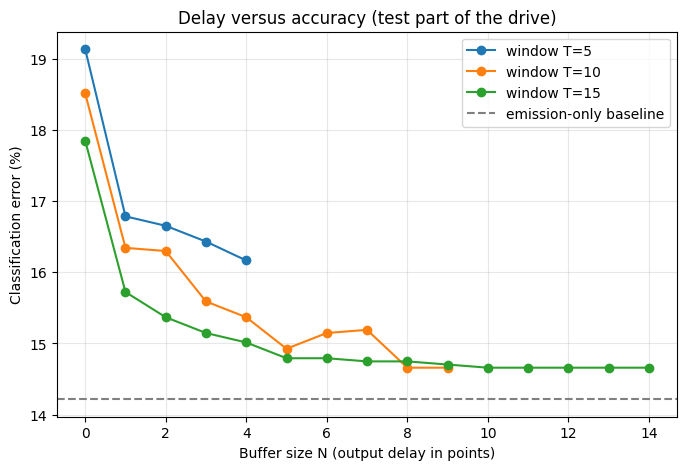

Best : T=10, N=8, error 0.1466  (paper best: 0.0033)
Worst: T=5, N=0, error 0.1913  (paper worst: 0.046)


In [134]:
results = []
for T in (5, 10, 15):
    for N in range(0, T):
        oe, od = run_sliding_viterbi(T, N)
        e_state, e_edge = evaluate(oe, od, from_idx=split_idx)
        f_state, _ = evaluate(oe, od)
        results.append(dict(T=T, N=N, test_error=e_state, test_error_edge_only=e_edge, full_error=f_state))
        print(f"T={T:2d} N={N:2d}  test error {e_state:.4f}")

res = pd.DataFrame(results)
res.to_csv("viterbi_delay_vs_accuracy.csv", index=False)

plt.figure(figsize=(8, 5))
for T, g in res.groupby("T"):
    plt.plot(g["N"], g["test_error"] * 100, marker="o", label=f"window T={T}")
plt.axhline(b_state * 100, linestyle="--", color="gray", label="emission-only baseline")
plt.xlabel("Buffer size N (output delay in points)")
plt.ylabel("Classification error (%)")
plt.title("Delay versus accuracy (test part of the drive)")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("delay_vs_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

best = res.loc[res["test_error"].idxmin()]
worst = res.loc[res["test_error"].idxmax()]
print(f"Best : T={int(best['T'])}, N={int(best['N'])}, error {best['test_error']:.4f}  (paper best: 0.0033)")
print(f"Worst: T={int(worst['T'])}, N={int(worst['N'])}, error {worst['test_error']:.4f}  (paper worst: 0.046)")


In [135]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, accuracy_score

def make_xgb(depth, spw):
    return XGBClassifier(n_estimators=100, max_depth=depth, learning_rate=0.1,
                         scale_pos_weight=spw,            # plays the role of class_weight="balanced"
                         eval_metric="logloss", n_jobs=-1, random_state=42)

def tune_and_fit_xgb(train, test, features, label, group_col,
                     depths=(2, 3, 4), n_folds=10):
    groups = np.sort(train[group_col].unique())
    folds = np.array_split(groups, n_folds)            # contiguous blocks, same as the SVM
    spw = (train[label] == 0).sum() / max((train[label] == 1).sum(), 1)
    rows = []
    for depth in depths:
        f1s, accs = [], []
        for f in folds:
            val = train[group_col].isin(f)
            m = make_xgb(depth, spw).fit(train.loc[~val, features], train.loc[~val, label])
            pred = m.predict(train.loc[val, features])
            f1s.append(f1_score(train.loc[val, label], pred, zero_division=0))
            accs.append(accuracy_score(train.loc[val, label], pred))
        rows.append((depth, np.mean(f1s), np.mean(accs)))
    cv_table = pd.DataFrame(rows, columns=["max_depth", "cv_f1", "cv_accuracy"])
    best_depth = int(cv_table.loc[cv_table["cv_f1"].idxmax(), "max_depth"])
    final = make_xgb(best_depth, spw).fit(train[features], train[label])
    pred = final.predict(test[features])
    print(cv_table.to_string(index=False))
    print("Best max_depth:", best_depth)
    print("Test F1:", round(f1_score(test[label], pred, zero_division=0), 4),
          "| Test accuracy:", round(accuracy_score(test[label], pred), 4))
    print("Feature importance:", dict(zip(features, np.round(final.feature_importances_, 3))))
    return final

print("=== Emission: XGBoost ===")
xgb_em = tune_and_fit_xgb(em_train, em_test, emission_features, "emission_label", "gps_index")
print("\n=== Transition: XGBoost ===")
xgb_tr = tune_and_fit_xgb(tr_train, tr_test, transition_features, "transition_label", "gps_index_curr")

def row(name, model, test, features, label):
    p = model.predict(test[features])
    return dict(model=name, F1=round(f1_score(test[label], p), 4), accuracy=round(accuracy_score(test[label], p), 4))

cls_table = pd.DataFrame([
    {"task": "emission", **row("SVM (reference)", emission_model, em_test, emission_features, "emission_label")},
    {"task": "emission", **row("XGBoost (extension)", xgb_em, em_test, emission_features, "emission_label")},
    {"task": "transition", **row("SVM (reference)", transition_model, tr_test, transition_features, "transition_label")},
    {"task": "transition", **row("XGBoost (extension)", xgb_tr, tr_test, transition_features, "transition_label")},
])
print("\n", cls_table.to_string(index=False))
cls_table.to_csv("classification_svm_vs_xgboost.csv", index=False)

=== Emission: XGBoost ===
 max_depth    cv_f1  cv_accuracy
         2 0.730166     0.902120
         3 0.717075     0.897245
         4 0.725820     0.902189
Best max_depth: 2
Test F1: 0.7145 | Test accuracy: 0.9027
Feature importance: {'location_emission_scaled': np.float32(0.676), 'orientation': np.float32(0.3), 'speed_constraint': np.float32(0.024)}

=== Transition: XGBoost ===
 max_depth    cv_f1  cv_accuracy
         2 0.583295     0.802601
         3 0.584323     0.803676
         4 0.584189     0.803574
Best max_depth: 3
Test F1: 0.5433 | Test accuracy: 0.8102
Feature importance: {'distance_discrepancy': np.float32(0.881), 'backtrack_prevention': np.float32(0.119)}

       task               model     F1  accuracy
  emission     SVM (reference) 0.5608    0.8208
  emission XGBoost (extension) 0.7145    0.9027
transition     SVM (reference) 0.4648    0.8673
transition XGBoost (extension) 0.5433    0.8102


In [136]:
from types import SimpleNamespace

EPS = 1e-6

# Emission scores = predicted probability that a candidate is the true road (one batch call)
p_em_all = np.clip(xgb_em.predict_proba(cand[emission_features].fillna(0))[:, 1], EPS, None)
S_xgb, pos = [], 0
for t in range(n_obs):
    k = len(S[t].edge_l)
    S_xgb.append(SimpleNamespace(edge_l=S[t].edge_l, dir_l=S[t].dir_l,
                                 em_l=np.log(p_em_all[pos:pos + k]).tolist(), mid=S[t].mid))
    pos += k
assert pos == len(cand)

# Transition scores: predict once for every (t, previous state, current state), for backtrack = 0 and 1
dd_parts, shapes = [], {}
for t in range(1, n_obs):
    a, b = S[t - 1].mid, S[t].mid
    d = np.sqrt(((a[:, None, :] - b[None, :, :]) ** 2).sum(axis=2))
    dd = 1.0 / (np.abs(move[t] - d) + 1.0)
    shapes[t] = dd.shape
    dd_parts.append(dd.ravel())
flat = np.concatenate(dd_parts)

def tr_log_probs(bt_value):
    X = pd.DataFrame({"distance_discrepancy": flat,
                      "backtrack_prevention": bt_value})[transition_features]
    return np.log(np.clip(xgb_tr.predict_proba(X)[:, 1], EPS, None))

lt0_flat, lt1_flat = tr_log_probs(0), tr_log_probs(1)

_lt_cache_xgb, pos = {}, 0
for t in range(1, n_obs):
    r, c = shapes[t]
    size = r * c
    _lt_cache_xgb[t] = (lt0_flat[pos:pos + size].reshape(r, c).tolist(),
                        lt1_flat[pos:pos + size].reshape(r, c).tolist())
    pos += size

def trans_tables_xgb(t):
    return _lt_cache_xgb[t]

def run_grid(T_list=(5, 10, 15), tag="XGB"):
    rows = []
    for T in T_list:
        for N in range(T):
            oe, od = run_sliding_viterbi(T, N)
            e_state, e_edge = evaluate(oe, od, from_idx=split_idx)
            rows.append(dict(T=T, N=N, test_error=e_state, test_error_edge_only=e_edge))
            print(f"[{tag}] T={T:2d} N={N:2d}  test error {e_state:.4f}")
    return pd.DataFrame(rows)

# Swap the HMM over to XGBoost scores, run, then swap back to the SVM version
S_svm, trans_tables_svm = S, trans_tables
S, trans_tables = S_xgb, trans_tables_xgb
try:
    res_xgb = run_grid()
finally:
    S, trans_tables = S_svm, trans_tables_svm
res_xgb.to_csv("viterbi_delay_vs_accuracy_xgboost.csv", index=False)

[XGB] T= 5 N= 0  test error 0.2564
[XGB] T= 5 N= 1  test error 0.2174
[XGB] T= 5 N= 2  test error 0.2033
[XGB] T= 5 N= 3  test error 0.1674
[XGB] T= 5 N= 4  test error 0.1630
[XGB] T=10 N= 0  test error 0.2498
[XGB] T=10 N= 1  test error 0.2130
[XGB] T=10 N= 2  test error 0.1988
[XGB] T=10 N= 3  test error 0.1647
[XGB] T=10 N= 4  test error 0.1608
[XGB] T=10 N= 5  test error 0.1594
[XGB] T=10 N= 6  test error 0.1581
[XGB] T=10 N= 7  test error 0.1568
[XGB] T=10 N= 8  test error 0.1568
[XGB] T=10 N= 9  test error 0.1563
[XGB] T=15 N= 0  test error 0.2383
[XGB] T=15 N= 1  test error 0.1940
[XGB] T=15 N= 2  test error 0.1723
[XGB] T=15 N= 3  test error 0.1665
[XGB] T=15 N= 4  test error 0.1670
[XGB] T=15 N= 5  test error 0.1594
[XGB] T=15 N= 6  test error 0.1577
[XGB] T=15 N= 7  test error 0.1568
[XGB] T=15 N= 8  test error 0.1568
[XGB] T=15 N= 9  test error 0.1563
[XGB] T=15 N=10  test error 0.1568
[XGB] T=15 N=11  test error 0.1572
[XGB] T=15 N=12  test error 0.1572
[XGB] T=15 N=13  tes

Best SVM    : T=10, N=8, error 0.1466
Best XGBoost: T=10, N=9, error 0.1563
Settings where XGBoost is better / equal / worse: 0 0 30
Average error difference (XGBoost - SVM): 0.0204


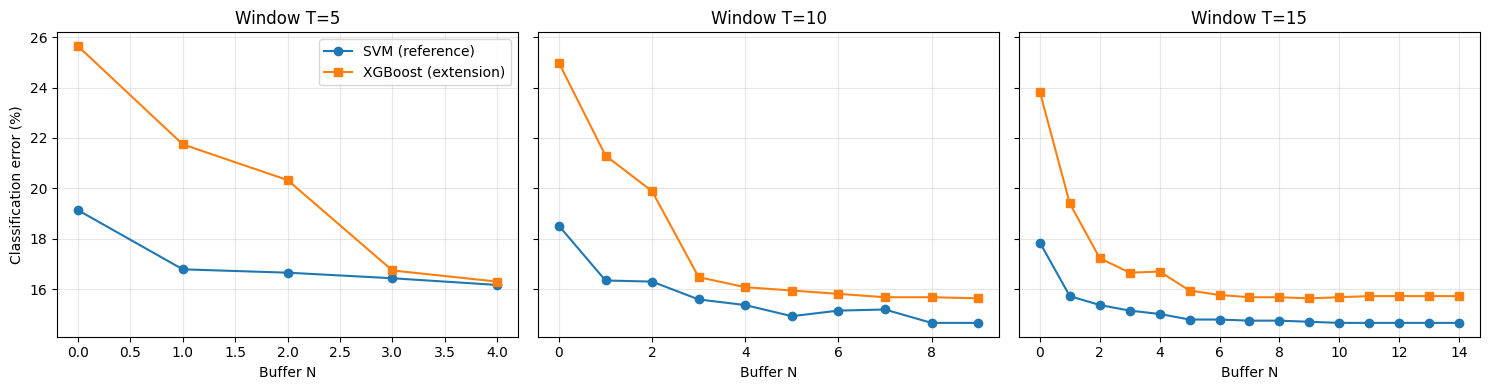

In [137]:
import matplotlib.pyplot as plt

cmp_ = res[["T", "N", "test_error"]].merge(
    res_xgb[["T", "N", "test_error"]], on=["T", "N"], suffixes=("_svm", "_xgb"))
cmp_["diff_xgb_minus_svm"] = cmp_["test_error_xgb"] - cmp_["test_error_svm"]
cmp_.to_csv("svm_vs_xgboost_comparison.csv", index=False)

best_svm = cmp_.loc[cmp_["test_error_svm"].idxmin()]
best_x = cmp_.loc[cmp_["test_error_xgb"].idxmin()]
print(f"Best SVM    : T={int(best_svm['T'])}, N={int(best_svm['N'])}, error {best_svm['test_error_svm']:.4f}")
print(f"Best XGBoost: T={int(best_x['T'])}, N={int(best_x['N'])}, error {best_x['test_error_xgb']:.4f}")
print("Settings where XGBoost is better / equal / worse:",
      int((cmp_["diff_xgb_minus_svm"] < -1e-4).sum()),
      int((cmp_["diff_xgb_minus_svm"].abs() <= 1e-4).sum()),
      int((cmp_["diff_xgb_minus_svm"] > 1e-4).sum()))
print("Average error difference (XGBoost - SVM):", round(cmp_["diff_xgb_minus_svm"].mean(), 4))

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (T, g) in zip(axes, cmp_.groupby("T")):
    ax.plot(g["N"], g["test_error_svm"] * 100, marker="o", label="SVM (reference)")
    ax.plot(g["N"], g["test_error_xgb"] * 100, marker="s", label="XGBoost (extension)")
    ax.set_title(f"Window T={T}")
    ax.set_xlabel("Buffer N")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("Classification error (%)")
axes[0].legend()
plt.tight_layout()
plt.savefig("svm_vs_xgboost.png", dpi=150, bbox_inches="tight")
plt.show()
